# Notebook 1: Baseline Comparison
## ACO vs Standard ALNS vs Hybrid ALNS on Both Datasets

This notebook runs the **baseline comparison experiment** per requirement point 6:

- **Algorithms**: ACO, Standard ALNS, Hybrid ALNS
- **Datasets**: A and B
- **Vehicle availability**: FULL (baseline fleet for each dataset)
- **Refill availability**: FULL (all refill stations active)
- **Computation budget**: same `max_iter` for all algorithms (computation_time is **measured**, not constrained, so it can be compared across algorithms)
- **Objective function**: identical across all algorithms
- **Independent runs**: 20 seeds per algorithm per dataset
- **Total runs**: 2 datasets x 3 algorithms x 20 seeds = 120 runs

**Output**:
- `baseline_dataset_a.csv`, `baseline_dataset_b.csv` (every run saved, not just best)
- Convergence plots, Gantt charts, and route maps for best run per algorithm per dataset
- Summary comparison table and charts


## 1. Data Loading

Load dataset (CSV + time matrix `.npy`) and derive model configuration from the `type` column.

In [26]:
import numpy as np
import pandas as pd
import random
import time
import os
import json
from copy import deepcopy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

os.makedirs('output-baseline', exist_ok=True)

# Operational constants (modify here if needed)
TRUCK_CAP           = 5000.0   # tank capacity (liters)
OP_WINDOW           = 540.0    # operational window (minutes) 06:00-15:00
SERVICE_TIME_FULL   = 20.0     # watering service time for 5000 L full (minutes)
SERVICE_TIME_REFILL = 5.0      # refill service time at station (minutes)
REFILL_PENALTY      = 2.0      # penalty per refill visit in objective
BALANCE_PENALTY     = 0.1      # penalty for route time imbalance

# Truck colors for map visualization
TRUCK_COLORS = ['#E53935','#1E88E5','#43A047','#FB8C00','#8E24AA',
                '#00ACC1','#D81B60','#6D4C41','#3949AB','#C0CA33',
                '#F4511E','#039BE5','#7CB342','#FFB300','#5E35B1']


In [27]:
# Dataset registry: adjust paths and baseline truck counts here.
# Truck count = fleet size for baseline (full vehicle availability).
# TODO: set the correct baseline truck count for each dataset.
DATASETS = {
    'Dataset A': {
        'csv'    : '../data/dataset_a.csv',
        'time'   : '../data/dataset_a_time_matrix.npy',
        'trucks' : 10,
    },
    'Dataset B': {
        'csv'    : '../data/dataset_b.csv',
        'time'   : '../data/dataset_b_time_matrix.npy',
        'trucks' : 5,
    },
}

# Global variables (populated by load_dataset)
nodes = time_mat = demands = None
DEPOT = PARK_IDX = REFILL_IDX = PARK_SET = REFILL_SET = None
ACTIVE_DATASET = None
ACTIVE_REFILLS = None  # subset of active refill stations (for Scenario 2)

def load_dataset(name):
    global nodes, time_mat, demands
    global DEPOT, PARK_IDX, REFILL_IDX, PARK_SET, REFILL_SET
    global ACTIVE_DATASET, ACTIVE_REFILLS
    cfg = DATASETS[name]
    nodes = pd.read_csv(cfg['csv'])
    time_mat = np.load(cfg['time'])
    demands = dict(zip(nodes['id'], nodes.get('demand', nodes.get('demand_liters', pd.Series([0]*len(nodes))))))
    DEPOT = nodes[nodes['type'] == 'depot']['id'].iloc[0]
    PARK_IDX = list(nodes[nodes['type'] == 'park']['id'])
    REFILL_IDX = list(nodes[nodes['type'] == 'refill']['id'])
    PARK_SET = set(PARK_IDX)
    REFILL_SET = set(REFILL_IDX)
    ACTIVE_DATASET = name
    ACTIVE_REFILLS = list(REFILL_IDX)  # default: all refills active
    print(f'Loaded {name}: {len(PARK_IDX)} parks, {len(REFILL_IDX)} refill stations, depot={DEPOT}')
    print(f'  Total demand: {sum(demands[nd] for nd in PARK_IDX):,.0f} L')
    print(f'  Time matrix shape: {time_mat.shape}')
    return name

def set_active_refills(refill_ids):
    """Set the subset of refill stations available to the solver (for Scenario 2)."""
    global ACTIVE_REFILLS
    ACTIVE_REFILLS = list(refill_ids)
    print(f'  Active refills set: {len(ACTIVE_REFILLS)}/{len(REFILL_IDX)} stations')


## 2. Core Functions (shared across all algorithms)

Route evaluation, route reconstruction with automatic refill insertion, initial solution construction, and penalized objective function. All algorithms use the same functions to ensure fair comparison.

In [28]:
# Route evaluation: accumulate travel + service + refill time, check time window.
# Each truck starts with an initial fill (empty tank -> fill at nearest ACTIVE refill).
def evaluate_route(route, delivery_amounts):
    current_time = 0.0
    refills_available = ACTIVE_REFILLS if ACTIVE_REFILLS else REFILL_IDX
    init_refill = min(refills_available, key=lambda r: float(time_mat[DEPOT][r]))
    current_time += float(time_mat[DEPOT][init_refill]) + SERVICE_TIME_REFILL
    current_load = float(TRUCK_CAP)
    violations = {}

    # Split delivery volume across multiple visits to the same park
    visit_order = {}
    for idx, nd in enumerate(route[1:-1], start=1):
        if nd in PARK_SET:
            visit_order.setdefault(nd, []).append(idx)
    visit_delivery = {}
    for nd, positions in visit_order.items():
        per = delivery_amounts.get(nd, 0) / len(positions)
        for p in positions:
            visit_delivery[p] = per

    for i in range(len(route) - 1):
        frm, to = route[i], route[i + 1]
        current_time += float(time_mat[frm][to])

        if to == DEPOT:
            if current_time > OP_WINDOW:
                violations['tw_return_depot'] = current_time - OP_WINDOW
            continue
        if to in PARK_SET:
            dv = visit_delivery.get(i + 1, 0)
            if dv <= 0:
                continue
            dv_actual = min(dv, current_load)
            current_load -= dv_actual
            current_time += SERVICE_TIME_FULL * (dv_actual / TRUCK_CAP)
        elif to in REFILL_SET:
            current_load = float(TRUCK_CAP)
            current_time += SERVICE_TIME_REFILL

        # Time window check including return-to-depot
        if current_time + float(time_mat[to][DEPOT]) > OP_WINDOW:
            violations[f'tw_{to}'] = (current_time + float(time_mat[to][DEPOT])) - OP_WINDOW

    return current_time, len(violations) == 0, violations


# Build route from park sequence: insert refill when tank runs out (handles demand > capacity)
def rebuild_route_with_refills(park_sequence, dmap_route):
    if not park_sequence:
        return [DEPOT, DEPOT]
    refills_available = ACTIVE_REFILLS if ACTIVE_REFILLS else REFILL_IDX
    route = [DEPOT]; load = float(TRUCK_CAP); pos = DEPOT
    for nd in park_sequence:
        remaining = dmap_route.get(nd, 0)
        if remaining <= 0:
            continue
        while remaining > 0.1:
            if load < 0.1:
                nr = min(refills_available, key=lambda r: float(time_mat[pos][r]))
                route.append(nr); load = float(TRUCK_CAP); pos = nr
            dv_actual = min(remaining, load)
            route.append(nd); load -= dv_actual; remaining -= dv_actual; pos = nd
            if remaining > 0.1 and load < 0.1:
                nr = min(refills_available, key=lambda r: float(time_mat[pos][r]))
                route.append(nr); load = float(TRUCK_CAP); pos = nr
    route.append(DEPOT)
    return route


# Rebuild all routes from delivery map
def rebuild_routes_from_dmap(dmap, n_trucks):
    return [rebuild_route_with_refills(
        [nd for nd in PARK_IDX if dmap[ri].get(nd, 0) > 0.1], dmap[ri])
        for ri in range(n_trucks)]


# Estimate initial refill overhead (used by constructors to match evaluate_route)
def _init_refill_time():
    refills_available = ACTIVE_REFILLS if ACTIVE_REFILLS else REFILL_IDX
    init_r = min(refills_available, key=lambda r: float(time_mat[DEPOT][r]))
    return float(time_mat[DEPOT][init_r]) + SERVICE_TIME_REFILL

print('evaluate_route, rebuild_route_with_refills, rebuild_routes_from_dmap ready.')

evaluate_route, rebuild_route_with_refills, rebuild_routes_from_dmap ready.


In [29]:
# Penalized objective function: total time + refill penalty + balance penalty + constraint violations
def evaluate_solution(solution, delivery_map):
    PENALTY = 1e6
    total_fitness = 0.0
    all_feasible = True

    # Demand fulfillment constraint (split delivery): sum f_ik = p_i
    delivered = {}
    for ri in range(len(solution)):
        for nd, amt in delivery_map[ri].items():
            delivered[nd] = delivered.get(nd, 0) + amt
    for nd in PARK_IDX:
        shortfall = demands[nd] - delivered.get(nd, 0)
        if shortfall > 0.1:
            total_fitness += PENALTY * (shortfall / TRUCK_CAP)
            all_feasible = False

    # Route time + refill penalty + time window violation penalty
    for ri, route in enumerate(solution):
        t, feas, viol = evaluate_route(route, delivery_map[ri])
        n_refill = sum(1 for nd in route[1:-1] if nd in REFILL_SET)
        total_fitness += t + n_refill * REFILL_PENALTY
        if not feas:
            all_feasible = False
            for v in viol.values():
                total_fitness += PENALTY * (v / OP_WINDOW)

    # Balance penalty: penalize route time variance across trucks
    times = [evaluate_route(r, delivery_map[ri])[0]
             for ri, r in enumerate(solution) if len(r) > 2]
    if len(times) > 1:
        total_fitness += BALANCE_PENALTY * float(np.std(times))

    # Penalty for empty trucks (no parks served)
    n_empty = sum(1 for r in solution
                  if sum(1 for nd in r[1:-1] if nd in PARK_SET) == 0)
    if n_empty > 0:
        total_fitness += PENALTY * n_empty
        all_feasible = False

    return total_fitness, all_feasible

print('evaluate_solution ready.')


evaluate_solution ready.


In [30]:
# Greedy nearest-neighbor initial solution with split delivery across trucks
def build_initial_solution(num_trucks, seed=None):
    rng = random.Random(seed)
    park_list = list(PARK_IDX); rng.shuffle(park_list)
    total_demand = sum(demands[nd] for nd in PARK_IDX)
    DEMAND_BUDGET = total_demand / num_trucks * 1.1
    remaining = {nd: float(demands[nd]) for nd in park_list}
    solution, delivery_map = [], {}
    refills_available = ACTIVE_REFILLS if ACTIVE_REFILLS else REFILL_IDX
    init_overhead = _init_refill_time()

    # Phase 1: fill each truck up to budget
    for tid in range(num_trucks):
        route, rdel = [DEPOT], {}
        load = float(TRUCK_CAP)
        cur_t = init_overhead
        pos = DEPOT; delivered_vol = 0.0
        while True:
            unmet = {nd: d for nd, d in remaining.items() if d > 0.1}
            if not unmet or delivered_vol >= DEMAND_BUDGET:
                break
            cands = []
            for nd, dem in unmet.items():
                tt = float(time_mat[pos][nd]); dv = min(load, dem)
                if dv <= 0:
                    continue
                ft = cur_t + tt + SERVICE_TIME_FULL * (dv / TRUCK_CAP)
                if ft + float(time_mat[nd][DEPOT]) <= OP_WINDOW:
                    cands.append((nd, tt, dv))
            if not cands:
                if load >= TRUCK_CAP - 0.1:
                    break
                nr = min(refills_available, key=lambda r: float(time_mat[pos][r]))
                tr = float(time_mat[pos][nr])
                if cur_t + tr + SERVICE_TIME_REFILL + float(time_mat[nr][DEPOT]) > OP_WINDOW:
                    break
                route.append(nr); cur_t += tr + SERVICE_TIME_REFILL
                load = float(TRUCK_CAP); pos = nr
                for nd, dem in unmet.items():
                    tt = float(time_mat[pos][nd]); dv = min(load, dem)
                    if dv <= 0:
                        continue
                    ft = cur_t + tt + SERVICE_TIME_FULL * (dv / TRUCK_CAP)
                    if ft + float(time_mat[nd][DEPOT]) <= OP_WINDOW:
                        cands.append((nd, tt, dv))
                if not cands:
                    break
            cands.sort(key=lambda x: x[1])
            nd, tt, dv = cands[0]
            dv = min(dv, DEMAND_BUDGET - delivered_vol)
            if dv <= 0:
                break
            dv = min(dv, remaining[nd])
            route.append(nd); rdel[nd] = rdel.get(nd, 0) + dv
            remaining[nd] -= dv; delivered_vol += dv; load -= dv
            cur_t += tt + SERVICE_TIME_FULL * (dv / TRUCK_CAP); pos = nd
            if load < 1.0:
                nr = min(refills_available, key=lambda r: float(time_mat[pos][r]))
                tr = float(time_mat[pos][nr])
                if cur_t + tr + SERVICE_TIME_REFILL + float(time_mat[nr][DEPOT]) <= OP_WINDOW:
                    route.append(nr); cur_t += tr + SERVICE_TIME_REFILL
                    load = float(TRUCK_CAP); pos = nr
        route.append(DEPOT); solution.append(route); delivery_map[tid] = rdel

    # Phase 2: distribute leftover demand to lightest trucks (feasible insertion)
    order = sorted(
        [(ri, evaluate_route(solution[ri], delivery_map[ri])[0] if len(solution[ri]) > 2 else 0.0)
         for ri in range(num_trucks)], key=lambda x: x[1])
    for ri, _ in order:
        while True:
            unmet = {nd: d for nd, d in remaining.items() if d > 0.1}
            if not unmet:
                break
            rdmap = delivery_map[ri]
            cur_t = evaluate_route(solution[ri], rdmap)[0] if len(solution[ri]) > 2 else init_overhead
            pos = solution[ri][-2] if len(solution[ri]) > 2 else DEPOT
            cands = []
            for nd, dem in unmet.items():
                tt = float(time_mat[pos][nd]); dv = min(TRUCK_CAP, dem)
                ft = cur_t + tt + SERVICE_TIME_FULL * (dv / TRUCK_CAP)
                if ft + float(time_mat[nd][DEPOT]) <= OP_WINDOW:
                    cands.append((nd, tt, dv))
            if not cands:
                break
            cands.sort(key=lambda x: x[1]); nd, tt, dv = cands[0]
            rdmap[nd] = rdmap.get(nd, 0) + dv; remaining[nd] -= dv
            seq = [n for n in PARK_IDX if rdmap.get(n, 0) > 0.1]
            solution[ri] = rebuild_route_with_refills(seq, rdmap)

    # Phase 3 (NEW): force-assign any remaining demand to ensure no shortfall.
    # May create time-window violations, but ALNS/Hybrid can fix those via iteration.
    # Demand shortfall is unrecoverable by destroy-repair, so this is critical.
    leftover = {nd: d for nd, d in remaining.items() if d > 0.1}
    if leftover:
        for nd, d in list(leftover.items()):
            if d <= 0.1:
                continue
            # Try each truck: prefer feasible insertion, fallback to lightest
            best_ri, best_cost = None, float('inf')
            for ri in range(num_trucks):
                tmp = dict(delivery_map[ri]); tmp[nd] = tmp.get(nd, 0) + d
                seq = [x for x in PARK_IDX if tmp.get(x, 0) > 0.1]
                route = rebuild_route_with_refills(seq, tmp)
                t, feas, _ = evaluate_route(route, tmp)
                cost = t if feas else t + 1e5
                if cost < best_cost:
                    best_cost, best_ri = cost, ri
            if best_ri is None:
                best_ri = min(range(num_trucks), key=lambda r: sum(delivery_map[r].values()))
            delivery_map[best_ri][nd] = delivery_map[best_ri].get(nd, 0) + d
            remaining[nd] = 0
            seq = [x for x in PARK_IDX if delivery_map[best_ri].get(x, 0) > 0.1]
            solution[best_ri] = rebuild_route_with_refills(seq, delivery_map[best_ri])

    return solution, delivery_map


# Ensure every truck has at least one park
def repair_empty_trucks(solution, delivery_map, num_trucks):
    for _ in range(num_trucks):
        empty = [i for i, r in enumerate(solution)
                 if sum(1 for nd in r[1:-1] if nd in PARK_SET) == 0]
        if not empty:
            break
        donors = [i for i in range(num_trucks)
                  if len([nd for nd in PARK_IDX if delivery_map[i].get(nd, 0) > 0.1]) >= 2]
        if not donors:
            break
        donor = max(donors, key=lambda i: len([nd for nd in PARK_IDX if delivery_map[i].get(nd, 0) > 0.1]))
        dparks = [nd for nd in PARK_IDX if delivery_map[donor].get(nd, 0) > 0.1]
        node = dparks[-1]; amt = delivery_map[donor][node]
        move = amt / 2.0; remain = amt - move
        if remain < 0.1:
            delivery_map[donor].pop(node, None)
        else:
            delivery_map[donor][node] = remain
        delivery_map[empty[0]] = {node: move}
        for ri in [donor, empty[0]]:
            seq = [nd for nd in PARK_IDX if delivery_map[ri].get(nd, 0) > 0.1]
            solution[ri] = rebuild_route_with_refills(seq, delivery_map[ri])
    return solution, delivery_map

print('build_initial_solution, repair_empty_trucks ready.')

build_initial_solution, repair_empty_trucks ready.


## 3. Unified Output Structure & Visualization

Identical output structure for all algorithms, plus convergence plot, Gantt chart, and interactive route map (Folium + OSRM).

In [31]:
# Unified output structure for a single run (identical across algorithms).
# Columns per requirement: total_time, makespan, route_time_std, active_vehicles,
# refill_visits, computation_time, feasible, and routes.
def compute_output(sol, dmap, convergence, comp_time):
    times = [evaluate_route(r, dmap[i])[0] for i, r in enumerate(sol) if len(r) > 2]
    _, feasible = evaluate_solution(sol, dmap)
    active = sum(1 for r in sol if sum(1 for nd in r[1:-1] if nd in PARK_SET) > 0)
    refills = sum(sum(1 for nd in r[1:-1] if nd in REFILL_SET)
                  for r in sol if len(r) > 2)
    return {
        'total_time'      : float(round(sum(times), 2)),
        'makespan'        : float(round(max(times), 2)) if times else 0.0,
        'route_time_std'  : float(round(np.std(times), 2)) if len(times) > 1 else 0.0,
        'active_vehicles' : int(active),
        'refill_visits'   : int(refills),
        'computation_time': float(round(comp_time, 3)),
        'feasible'        : bool(feasible),
        'solution'        : sol,
        'dmap'            : dmap,
        'convergence'     : convergence,
    }

print('compute_output ready.')


compute_output ready.


In [32]:
# Convergence plot: best run panel + all runs panel
def plot_convergence(all_conv, best_run_idx, algo, dataset, out_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    best = all_conv[best_run_idx]
    ax1.plot(best, color='#1565C0', linewidth=2)
    ax1.fill_between(range(len(best)), best, alpha=0.15, color='#1565C0')
    ax1.set_title(f'Best Run - {algo}', fontweight='bold')
    ax1.set_xlabel('Iteration'); ax1.set_ylabel('Fitness'); ax1.grid(alpha=0.3)
    for i, c in enumerate(all_conv):
        if i == best_run_idx:
            ax2.plot(c, color='red', linewidth=2.5, zorder=5, label='Best run')
        else:
            ax2.plot(c, color='#90CAF9', linewidth=0.9, alpha=0.7)
    ax2.set_title(f'All {len(all_conv)} Runs - {algo}', fontweight='bold')
    ax2.set_xlabel('Iteration'); ax2.set_ylabel('Fitness'); ax2.grid(alpha=0.3); ax2.legend()
    fig.suptitle(f'Convergence - {algo} - {dataset}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(out_path, dpi=140, bbox_inches='tight'); plt.show(); plt.close(fig)

print('plot_convergence ready.')


# Gantt chart: operational schedule per truck
def get_gantt_timeline(route, rdmap):
    T_START = 360.0
    timeline = []
    refills_available = ACTIVE_REFILLS if ACTIVE_REFILLS else REFILL_IDX
    pv = {}
    for nd in route[1:-1]:
        if nd in PARK_SET:
            pv[nd] = pv.get(nd, 0) + 1
    pdel = {nd: rdmap.get(nd, 0) / c for nd, c in pv.items()}
    init_r = min(refills_available, key=lambda r: float(time_mat[DEPOT][r]))
    tr0 = float(time_mat[DEPOT][init_r])
    timeline.append((T_START, tr0, 'travel'))
    timeline.append((T_START + tr0, SERVICE_TIME_REFILL, 'refill'))
    t = tr0 + SERVICE_TIME_REFILL; load = float(TRUCK_CAP)
    for i in range(len(route) - 1):
        frm, to = route[i], route[i + 1]
        tt = float(time_mat[frm][to])
        if tt > 0.01:
            timeline.append((T_START + t, tt, 'travel'))
        t += tt
        if to == DEPOT:
            break
        if to in PARK_SET:
            dv = min(pdel.get(to, 0), load); load -= dv
            st = SERVICE_TIME_FULL * (dv / TRUCK_CAP) if dv > 0 else 0
            if st > 0.01:
                timeline.append((T_START + t, st, 'park'))
            t += st
        elif to in REFILL_SET:
            load = float(TRUCK_CAP)
            timeline.append((T_START + t, SERVICE_TIME_REFILL, 'refill')); t += SERVICE_TIME_REFILL
    return timeline, T_START + t


def plot_gantt(sol, dmap, algo, dataset, out_path):
    active = [(tid, r, dmap[tid]) for tid, r in enumerate(sol) if len(r) > 2]
    fig, ax = plt.subplots(figsize=(16, max(4, len(active) * 1.0 + 1.5)))
    COLOR = {'park': '#43A047', 'refill': '#1E88E5', 'travel': '#E0E0E0'}
    yt, yl = [], []
    for y, (tid, route, rdmap) in enumerate(active):
        yt.append(y); yl.append(f'Truck {tid + 1}')
        timeline, finish = get_gantt_timeline(route, rdmap)
        for start, dur, kind in timeline:
            ax.barh(y, dur, left=start, height=0.8, color=COLOR[kind])
        ax.text(finish + 4, y, f'{finish - 360:.0f} min', va='center', fontsize=9)
    end_min = 360 + OP_WINDOW
    ax.axvline(end_min, color='red', linestyle='--', linewidth=1.6, alpha=0.85)
    ax.text(end_min + 1, len(active) - 0.5, f'{int(end_min//60):02d}:{int(end_min%60):02d}',
            color='red', fontsize=9, va='top')
    ticks = list(range(360, int(end_min) + 61, 60))
    ax.set_xticks(ticks); ax.set_xticklabels([f'{m//60:02d}:00' for m in ticks], fontsize=9)
    ax.set_xlim(355, end_min + 70)
    ax.set_yticks(yt); ax.set_yticklabels(yl, fontsize=10)
    ax.set_ylim(-0.6, len(active) - 0.4)
    ax.set_xlabel('Time')
    ax.set_title(f'Gantt Chart - {algo} - {dataset}', fontweight='bold')
    ax.legend(handles=[mpatches.Patch(color='#43A047', label='Park service'),
                       mpatches.Patch(color='#1E88E5', label='Refill'),
                       mpatches.Patch(color='#E0E0E0', label='Travel')],
              loc='lower right', fontsize=9)
    ax.grid(axis='x', alpha=0.25)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.savefig(out_path, dpi=140, bbox_inches='tight'); plt.show(); plt.close(fig)

print('plot_gantt ready.')


plot_convergence ready.
plot_gantt ready.


In [33]:
# Interactive route map (Folium + OSRM road-following geometry).
# Set USE_OSRM=False for straight-line fallback (no internet needed).
USE_OSRM = True

def _osrm_geom(waypoints_latlon, timeout=12, chunk_size=8):
    if not USE_OSRM:
        return [[la, lo] for la, lo in waypoints_latlon]
    import requests
    n = len(waypoints_latlon)
    if n < 2:
        return []
    all_coords = []; i = 0; chunks = []
    while i < n - 1:
        end = min(i + chunk_size, n); chunks.append(waypoints_latlon[i:end])
        if end == n:
            break
        i = end - 1
    for chunk in chunks:
        cs = ';'.join(f'{lo:.6f},{la:.6f}' for la, lo in chunk)
        url = f'http://router.project-osrm.org/route/v1/driving/{cs}?overview=full&geometries=geojson'
        try:
            resp = requests.get(url, timeout=timeout).json()
            if resp.get('code') == 'Ok':
                pts = [[c[1], c[0]] for c in resp['routes'][0]['geometry']['coordinates']]
                all_coords.extend(pts[1:] if all_coords else pts)
            else:
                fb = [[la, lo] for la, lo in chunk]
                all_coords.extend(fb[1:] if all_coords else fb)
        except Exception:
            fb = [[la, lo] for la, lo in chunk]
            all_coords.extend(fb[1:] if all_coords else fb)
        time.sleep(0.1)
    return all_coords


def build_route_map(sol, dmap, algo, dataset, out_path):
    import folium
    lat_col = 'lat' if 'lat' in nodes.columns else 'latitude'
    lon_col = 'lon' if 'lon' in nodes.columns else 'longitude'
    name_col = 'name' if 'name' in nodes.columns else 'id'
    demand_col = next((c for c in ['demand_liters','demand'] if c in nodes.columns), None)

    depot_row = nodes[nodes['type'].str.lower() == 'depot'].iloc[0]
    m = folium.Map(location=[depot_row[lat_col], depot_row[lon_col]],
                   zoom_start=13, tiles='cartodbpositron')

    for tid, route in enumerate(sol):
        if len(route) <= 2:
            continue
        color = TRUCK_COLORS[tid % len(TRUCK_COLORS)]
        wps = [(nodes.iloc[nd][lat_col], nodes.iloc[nd][lon_col]) for nd in route]
        geom = _osrm_geom(wps)
        nP = len(set(nd for nd in route[1:-1] if nd in PARK_SET))
        nR = sum(1 for nd in route[1:-1] if nd in REFILL_SET)
        fg = folium.FeatureGroup(name=f'Truck {tid + 1} ({nP} parks, {nR} refills)', show=True)
        if len(geom) >= 2:
            folium.PolyLine(geom, color='white', weight=6, opacity=0.6).add_to(fg)
            folium.PolyLine(geom, color=color, weight=4, opacity=0.9,
                            tooltip=f'Truck {tid + 1} | {nP} parks | {nR} refills').add_to(fg)
        pseq = rseq = 0
        for nd in route[1:-1]:
            row = nodes.iloc[nd]
            if nd in PARK_SET:
                pseq += 1
                dem_str = f' | {row[demand_col]:,.0f} L' if demand_col else ''
                html = (f'<div style="background:#c8e6c9;color:#1a1a1a;width:28px;height:28px;'
                        f'border-radius:50%;border:3px solid {color};display:flex;align-items:center;'
                        f'justify-content:center;font-weight:bold;font-size:11px;">{pseq}</div>')
                folium.Marker([row[lat_col], row[lon_col]],
                              tooltip=f'{row[name_col]}{dem_str}',
                              icon=folium.DivIcon(html=html, icon_size=(28, 28),
                                                  icon_anchor=(14, 14))).add_to(fg)
            elif nd in REFILL_SET:
                rseq += 1
                html = (f'<div style="background:#1565C0;color:white;width:26px;height:26px;'
                        f'border-radius:50%;display:flex;align-items:center;justify-content:center;'
                        f'font-weight:bold;font-size:10px;">R{rseq}</div>')
                folium.Marker([row[lat_col], row[lon_col]], tooltip=f'Refill: {row[name_col]}',
                              icon=folium.DivIcon(html=html, icon_size=(26, 26),
                                                  icon_anchor=(13, 13))).add_to(fg)
        fg.add_to(m)

    folium.Marker([depot_row[lat_col], depot_row[lon_col]],
                  tooltip=f'Depot: {depot_row[name_col]}',
                  icon=folium.Icon(color='gray', icon='home', prefix='fa')).add_to(m)
    title = (f'<div style="position:fixed;top:12px;left:50%;transform:translateX(-50%);'
             f'z-index:9999;background:rgba(255,255,255,0.95);padding:6px 18px;border-radius:8px;'
             f'border:2px solid #1565C0;font-family:Arial;font-size:13px;font-weight:bold;'
             f'color:#1565C0;">{algo} - {dataset} - Park Watering Routes</div>')
    m.get_root().html.add_child(folium.Element(title))
    folium.LayerControl(collapsed=False).add_to(m)
    m.save(out_path)
    print(f'Map saved: {out_path}')
    return m

print('build_route_map ready (USE_OSRM =', USE_OSRM, ').')


build_route_map ready (USE_OSRM = True ).


## 4. ACO (Ant Colony Optimization)

Each ant constructs a complete solution: parks selected probabilistically via `pheromone^alpha * heuristic^beta`. Pheromone updated via evaporation + deposit from iteration-best and global-best solutions.

In [34]:
# ACO: Ant Colony Optimization
# Each ant constructs a full solution probabilistically (pheromone^alpha * heuristic^beta).
# Pheromone updated via evaporation + deposit from iteration-best and global-best.
# Stopping criterion: max_iter (computation_time is measured, not constrained).

def _rebalance_solution(dmap, num_trucks, max_passes=10):
    """Move parks from heaviest trucks to lightest until balanced."""
    for _ in range(max_passes):
        # Compute route time per truck
        times = {}
        for ri in range(num_trucks):
            seq = [x for x in PARK_IDX if dmap[ri].get(x, 0) > 0.1]
            if seq:
                route = rebuild_route_with_refills(seq, dmap[ri])
                times[ri] = evaluate_route(route, dmap[ri])[0]
            else:
                times[ri] = 0.0

        heaviest = max(range(num_trucks), key=lambda r: times[r])
        lightest = min(range(num_trucks), key=lambda r: times[r])
        gap = times[heaviest] - times[lightest]

        # Stop if gap is small enough (< 15% of mean)
        mean_t = sum(times.values()) / num_trucks
        if mean_t < 1.0 or gap < mean_t * 0.15:
            break

        # Find best park to move from heaviest to lightest
        heavy_parks = [nd for nd in PARK_IDX if dmap[heaviest].get(nd, 0) > 0.1]
        if len(heavy_parks) <= 1:
            break

        best_move = None
        best_new_gap = gap
        for nd in heavy_parks:
            amt = dmap[heaviest][nd]
            # Try moving full amount
            tmp_h = dict(dmap[heaviest]); tmp_h.pop(nd)
            tmp_l = dict(dmap[lightest]); tmp_l[nd] = tmp_l.get(nd, 0) + amt

            seq_h = [x for x in PARK_IDX if tmp_h.get(x, 0) > 0.1]
            seq_l = [x for x in PARK_IDX if tmp_l.get(x, 0) > 0.1]
            if not seq_h:
                continue
            route_h = rebuild_route_with_refills(seq_h, tmp_h)
            route_l = rebuild_route_with_refills(seq_l, tmp_l)
            t_h, feas_h, _ = evaluate_route(route_h, tmp_h)
            t_l, feas_l, _ = evaluate_route(route_l, tmp_l)

            if not feas_l:
                # Try moving half
                half = amt / 2
                tmp_h2 = dict(dmap[heaviest]); tmp_h2[nd] = half
                tmp_l2 = dict(dmap[lightest]); tmp_l2[nd] = tmp_l2.get(nd, 0) + half
                seq_h2 = [x for x in PARK_IDX if tmp_h2.get(x, 0) > 0.1]
                seq_l2 = [x for x in PARK_IDX if tmp_l2.get(x, 0) > 0.1]
                route_h2 = rebuild_route_with_refills(seq_h2, tmp_h2)
                route_l2 = rebuild_route_with_refills(seq_l2, tmp_l2)
                t_h2, feas_h2, _ = evaluate_route(route_h2, tmp_h2)
                t_l2, feas_l2, _ = evaluate_route(route_l2, tmp_l2)
                if feas_l2:
                    new_gap = abs(t_h2 - t_l2)
                    if new_gap < best_new_gap:
                        best_new_gap = new_gap
                        best_move = ('half', nd, half)
                continue

            new_gap = abs(t_h - t_l)
            if new_gap < best_new_gap:
                best_new_gap = new_gap
                best_move = ('full', nd, amt)

        if best_move is None:
            break

        kind, nd, amt = best_move
        if kind == 'full':
            dmap[heaviest].pop(nd)
            dmap[lightest][nd] = dmap[lightest].get(nd, 0) + amt
        else:
            dmap[heaviest][nd] -= amt
            if dmap[heaviest][nd] < 0.1:
                dmap[heaviest].pop(nd)
            dmap[lightest][nd] = dmap[lightest].get(nd, 0) + amt

    sol = rebuild_routes_from_dmap(dmap, num_trucks)
    return sol, dmap


def _ant_construct(pher, alpha, beta, num_trucks, budget_factor, rng):
    remaining = {nd: float(demands[nd]) for nd in PARK_IDX}
    total_demand = sum(remaining.values())
    budget = total_demand / num_trucks * budget_factor
    dmap = {ri: {} for ri in range(num_trucks)}
    refills_available = ACTIVE_REFILLS if ACTIVE_REFILLS else REFILL_IDX
    init_overhead = _init_refill_time()

    for tid in range(num_trucks):
        pos = DEPOT
        cur_t = init_overhead
        load = float(TRUCK_CAP); delivered_vol = 0.0
        while delivered_vol < budget:
            unmet = {nd: d for nd, d in remaining.items() if d > 0.1}
            if not unmet:
                break
            cands = []
            for nd, dem in unmet.items():
                dv = min(load, dem)
                if dv <= 0:
                    continue
                ft = cur_t + float(time_mat[pos][nd]) + SERVICE_TIME_FULL * (dv / TRUCK_CAP)
                if ft + float(time_mat[nd][DEPOT]) <= OP_WINDOW:
                    cands.append(nd)
            if not cands:
                if load >= TRUCK_CAP - 0.1:
                    break
                nr = min(refills_available, key=lambda r: float(time_mat[pos][r]))
                tr = float(time_mat[pos][nr])
                if cur_t + tr + SERVICE_TIME_REFILL + float(time_mat[nr][DEPOT]) > OP_WINDOW:
                    break
                cur_t += tr + SERVICE_TIME_REFILL; load = float(TRUCK_CAP); pos = nr
                continue
            weights = []
            for nd in cands:
                tau = pher[pos][nd] ** alpha
                eta = (1.0 / (float(time_mat[pos][nd]) + 1e-6)) ** beta
                weights.append(tau * eta)
            tot = sum(weights)
            if tot <= 0:
                nd = rng.choice(cands)
            else:
                r = rng.random() * tot; acc = 0.0; nd = cands[-1]
                for c, w in zip(cands, weights):
                    acc += w
                    if acc >= r:
                        nd = c; break
            dv = min(load, remaining[nd], budget - delivered_vol)
            if dv <= 0:
                break
            dmap[tid][nd] = dmap[tid].get(nd, 0) + dv
            remaining[nd] -= dv; delivered_vol += dv; load -= dv
            cur_t += float(time_mat[pos][nd]) + SERVICE_TIME_FULL * (dv / TRUCK_CAP); pos = nd
            if load < 1.0:
                nr = min(refills_available, key=lambda r: float(time_mat[pos][r]))
                tr = float(time_mat[pos][nr])
                if cur_t + tr + SERVICE_TIME_REFILL + float(time_mat[nr][DEPOT]) <= OP_WINDOW:
                    cur_t += tr + SERVICE_TIME_REFILL; load = float(TRUCK_CAP); pos = nr

    # Distribute leftover demand across ALL trucks with remaining capacity
    leftover = {nd: d for nd, d in remaining.items() if d > 0.1}
    if leftover:
        for nd, d in list(leftover.items()):
            if d <= 0.1:
                continue
            order = sorted(range(num_trucks), key=lambda ri: sum(dmap[ri].values()))
            for ri in order:
                if d <= 0.1:
                    break
                tmp = dict(dmap[ri]); tmp[nd] = tmp.get(nd, 0) + d
                seq = [x for x in PARK_IDX if tmp.get(x, 0) > 0.1]
                route = rebuild_route_with_refills(seq, tmp)
                t, feas, _ = evaluate_route(route, tmp)
                if feas:
                    dmap[ri][nd] = dmap[ri].get(nd, 0) + d
                    d = 0
                else:
                    partial = d / 2
                    while partial > 0.1:
                        tmp2 = dict(dmap[ri]); tmp2[nd] = tmp2.get(nd, 0) + partial
                        seq2 = [x for x in PARK_IDX if tmp2.get(x, 0) > 0.1]
                        route2 = rebuild_route_with_refills(seq2, tmp2)
                        t2, feas2, _ = evaluate_route(route2, tmp2)
                        if feas2:
                            dmap[ri][nd] = dmap[ri].get(nd, 0) + partial
                            d -= partial
                            break
                        partial /= 2
            if d > 0.1:
                lightest = min(range(num_trucks), key=lambda ri: sum(dmap[ri].values()))
                dmap[lightest][nd] = dmap[lightest].get(nd, 0) + d

    # Ensure no empty trucks, then rebalance workload
    sol = rebuild_routes_from_dmap(dmap, num_trucks)
    sol, dmap = repair_empty_trucks(sol, dmap, num_trucks)
    sol, dmap = _rebalance_solution(dmap, num_trucks)
    return sol, dmap


def run_aco(num_trucks=5, n_ants=20, max_iter=100, alpha=1.0, beta=2.0,
            rho=0.1, q0=1.0, budget_factor=1.15, seed=None, verbose=False):
    if seed is not None:
        random.seed(seed); np.random.seed(seed)
    rng = random.Random(seed)
    t0 = time.time()
    N = len(nodes)
    pher = np.ones((N, N))
    best_sol = best_dmap = None; best_fit = float('inf'); convergence = []

    for it in range(max_iter):
        iter_best_fit = float('inf'); iter_best = None
        for _ in range(n_ants):
            sol, dmap = _ant_construct(pher, alpha, beta, num_trucks, budget_factor, rng)
            fit, _ = evaluate_solution(sol, dmap)
            if fit < iter_best_fit:
                iter_best_fit = fit; iter_best = (sol, dmap)
        if iter_best_fit < best_fit:
            best_fit = iter_best_fit
            best_sol = deepcopy(iter_best[0]); best_dmap = deepcopy(iter_best[1])
        pher *= (1.0 - rho)
        for fit_s, sol_s in [(iter_best_fit, iter_best[0]), (best_fit, best_sol)]:
            deposit = q0 / (fit_s + 1e-9)
            for route in sol_s:
                for a, b in zip(route[:-1], route[1:]):
                    pher[a][b] += deposit; pher[b][a] += deposit
        convergence.append(best_fit)
        if verbose and (it + 1) % 20 == 0:
            print(f'  ACO iter {it+1}/{max_iter} best={best_fit:,.1f}')
    return best_sol, best_dmap, best_fit, convergence, time.time() - t0

print('run_aco ready.')

run_aco ready.


## 5. Standard ALNS (Adaptive Large Neighborhood Search)

Iteratively destroys and repairs parts of the solution. Operator weights updated adaptively based on contribution. Simulated annealing acceptance criterion.

- **Destroy**: `random`, `worst` (most expensive parks), `related` (Shaw / geographically close)
- **Repair**: `greedy` (cheapest insertion), `regret-2` (largest gap between top-2 trucks)

In [35]:
# ALNS destroy and repair operators (shared by Standard ALNS and Hybrid ALNS)

def _all_assignments(dmap, n):
    return [(ri, nd) for ri in range(n)
            for nd in PARK_IDX if dmap[ri].get(nd, 0) > 0.1]

# --- Destroy operators ---
def destroy_random(dmap, n, k, rng):
    d = {ri: dict(dmap[ri]) for ri in range(n)}
    asg = _all_assignments(d, n); k = min(k, len(asg)); removed = []
    for ri, nd in rng.sample(asg, k):
        amt = d[ri].pop(nd, 0)
        if amt > 0.1:
            removed.append((nd, amt))
    return d, removed

def destroy_worst(dmap, n, k, rng):
    d = {ri: dict(dmap[ri]) for ri in range(n)}
    costs = []
    for ri in range(n):
        base = evaluate_route(rebuild_route_with_refills(
            [x for x in PARK_IDX if d[ri].get(x, 0) > 0.1], d[ri]), d[ri])[0]
        for nd in list(d[ri].keys()):
            tmp = dict(d[ri]); tmp.pop(nd, None)
            t2 = evaluate_route(rebuild_route_with_refills(
                [x for x in PARK_IDX if tmp.get(x, 0) > 0.1], tmp), tmp)[0]
            costs.append((base - t2, ri, nd))
    costs.sort(reverse=True); k = min(k, len(costs)); removed = []
    for _, ri, nd in costs[:k]:
        amt = d[ri].pop(nd, 0)
        if amt > 0.1:
            removed.append((nd, amt))
    return d, removed

def destroy_related(dmap, n, k, rng):
    d = {ri: dict(dmap[ri]) for ri in range(n)}
    asg = _all_assignments(d, n)
    if not asg:
        return d, []
    seed_ri, seed_nd = rng.choice(asg)
    ranked = sorted(asg, key=lambda x: float(time_mat[seed_nd][x[1]]))
    removed = []
    for ri, nd in ranked[:min(k, len(ranked))]:
        amt = d[ri].pop(nd, 0)
        if amt > 0.1:
            removed.append((nd, amt))
    return d, removed

# --- Repair operators ---
def _best_insert(nd, amt, dmap, n):
    best_ri, best_t = None, float('inf')
    for ri in range(n):
        tmp = dict(dmap[ri]); tmp[nd] = tmp.get(nd, 0) + amt
        seq = [x for x in PARK_IDX if tmp.get(x, 0) > 0.1]
        t, feas, _ = evaluate_route(rebuild_route_with_refills(seq, tmp), tmp)
        if feas and t < best_t:
            best_t, best_ri = t, ri
    return best_ri, best_t

def repair_greedy(dmap, removed, n, rng):
    d = {ri: dict(dmap[ri]) for ri in range(n)}
    for nd, amt in removed:
        ri, _ = _best_insert(nd, amt, d, n)
        if ri is None:
            ri = min(range(n), key=lambda r: sum(d[r].values()))
        d[ri][nd] = d[ri].get(nd, 0) + amt
    return d

def repair_regret(dmap, removed, n, rng):
    d = {ri: dict(dmap[ri]) for ri in range(n)}
    pending = list(removed)
    while pending:
        best_choice = None; best_regret = -1
        for nd, amt in pending:
            costs = []
            for ri in range(n):
                tmp = dict(d[ri]); tmp[nd] = tmp.get(nd, 0) + amt
                seq = [x for x in PARK_IDX if tmp.get(x, 0) > 0.1]
                t, feas, _ = evaluate_route(rebuild_route_with_refills(seq, tmp), tmp)
                if feas:
                    costs.append((t, ri))
            if not costs:
                costs = [(sum(d[ri].values()), ri) for ri in range(n)]
            costs.sort()
            regret = (costs[1][0] - costs[0][0]) if len(costs) > 1 else costs[0][0]
            if regret > best_regret:
                best_regret = regret; best_choice = (nd, amt, costs[0][1])
        nd, amt, ri = best_choice
        d[ri][nd] = d[ri].get(nd, 0) + amt
        pending = [(x, a) for (x, a) in pending if not (x == nd and abs(a - amt) < 1e-6)]
    return d

print('Destroy & repair operators ready.')


Destroy & repair operators ready.


In [36]:
# Standard ALNS: adaptive operator weights + simulated annealing acceptance.
# Stopping criterion: max_iter. computation_time is measured, not constrained.
def run_alns(num_trucks=5, max_iter=200, seed=None, verbose=False,
             sa_T0=100.0, sa_cool=0.995, seg=20, react=0.1):
    if seed is not None:
        random.seed(seed); np.random.seed(seed)
    rng = random.Random(seed)
    t0 = time.time()

    sol, dmap = build_initial_solution(num_trucks, seed=seed)
    sol, dmap = repair_empty_trucks(sol, dmap, num_trucks)
    cur_dmap = {ri: dict(dmap[ri]) for ri in range(num_trucks)}
    cur_fit = evaluate_solution(rebuild_routes_from_dmap(cur_dmap, num_trucks), cur_dmap)[0]
    best_dmap = deepcopy(cur_dmap); best_fit = cur_fit

    destroys = [destroy_random, destroy_worst, destroy_related]
    repairs = [repair_greedy, repair_regret]
    dw = [1.0] * len(destroys); rw = [1.0] * len(repairs)
    ds = [0.0] * len(destroys); rs = [0.0] * len(repairs)
    dc = [0] * len(destroys); rc = [0] * len(repairs)
    T = sa_T0; convergence = [best_fit]

    def pick(weights):
        tot = sum(weights); r = rng.random() * tot; acc = 0
        for i, w in enumerate(weights):
            acc += w
            if acc >= r:
                return i
        return len(weights) - 1

    for it in range(max_iter):
        di = pick(dw); ri_ = pick(rw)
        k = rng.randint(1, max(2, len(PARK_IDX) // 4))
        d_partial, removed = destroys[di](cur_dmap, num_trucks, k, rng)
        if not removed:
            convergence.append(best_fit); continue
        new_dmap = repairs[ri_](d_partial, removed, num_trucks, rng)
        new_sol = rebuild_routes_from_dmap(new_dmap, num_trucks)
        new_sol, new_dmap = repair_empty_trucks(new_sol, new_dmap, num_trucks)
        new_fit = evaluate_solution(new_sol, new_dmap)[0]
        dc[di] += 1; rc[ri_] += 1; score = 0.0
        if new_fit < best_fit - 1e-6:
            best_fit = new_fit; best_dmap = deepcopy(new_dmap)
            cur_dmap, cur_fit = new_dmap, new_fit; score = 3.0
        elif new_fit < cur_fit - 1e-6:
            cur_dmap, cur_fit = new_dmap, new_fit; score = 2.0
        elif rng.random() < np.exp(-(new_fit - cur_fit) / max(T, 1e-6)):
            cur_dmap, cur_fit = new_dmap, new_fit; score = 1.0
        ds[di] += score; rs[ri_] += score
        T = max(T * sa_cool, 1e-3)
        if (it + 1) % seg == 0:
            for i in range(len(dw)):
                if dc[i] > 0:
                    dw[i] = (1 - react) * dw[i] + react * (ds[i] / dc[i])
                ds[i] = 0.0; dc[i] = 0
            for i in range(len(rw)):
                if rc[i] > 0:
                    rw[i] = (1 - react) * rw[i] + react * (rs[i] / rc[i])
                rs[i] = 0.0; rc[i] = 0
        convergence.append(best_fit)
        if verbose and (it + 1) % 50 == 0:
            print(f'  ALNS iter {it+1}/{max_iter} best={best_fit:,.1f} T={T:.2f}')
    best_sol = rebuild_routes_from_dmap(best_dmap, num_trucks)
    best_sol, best_dmap = _rebalance_solution(best_dmap, num_trucks)
    best_fit, _ = evaluate_solution(best_sol, best_dmap)
    return best_sol, best_dmap, best_fit, convergence, time.time() - t0

print('run_alns ready.')


run_alns ready.


## 6. Hybrid ALNS + ACO

Combines ACO construction with ALNS intensification:

1. **ACO phase**: short ACO run to build quality initial solution and initialize pheromone matrix.
2. **ALNS phase**: adaptive destroy/repair with additional `repair_aco_guided` operator (truck selection guided by pheromone trail). Every new best solution reinforces pheromone (ACO feedback).

In [37]:
# Hybrid ALNS + ACO
# Phase 1: short ACO run to build quality initial solution + initialize pheromone matrix.
# Phase 2: ALNS with adaptive operators including ACO-guided repair.
# Pheromone feedback: reinforced on each new best solution found during ALNS phase.

def repair_aco_guided(dmap, removed, n, rng, pher, alpha=3.0, beta=1.0):
    d = {ri: dict(dmap[ri]) for ri in range(n)}
    for nd, amt in removed:
        weights = []
        for ri in range(n):
            tmp = dict(d[ri]); tmp[nd] = tmp.get(nd, 0) + amt
            seq = [x for x in PARK_IDX if tmp.get(x, 0) > 0.1]
            route_built = rebuild_route_with_refills(seq, tmp)
            t, feas, _ = evaluate_route(route_built, tmp)
            if not feas:
                weights.append(0.0); continue

            # FIX 2: cari predecessor sebenarnya di rute yang sudah dibangun
            if nd in route_built:
                idx = route_built.index(nd)
                last = route_built[idx - 1] if idx > 0 else DEPOT
            else:
                last = DEPOT

            tau = pher[last][nd] ** alpha
            eta = (1.0 / (t + 1e-6)) ** beta
            weights.append(tau * eta)

        tot = sum(weights)
        if tot <= 0:
            ri = min(range(n), key=lambda r: sum(d[r].values()))
        else:
            r = rng.random() * tot; acc = 0.0; ri = n - 1
            for i, w in enumerate(weights):
                acc += w
                if acc >= r:
                    ri = i; break
        d[ri][nd] = d[ri].get(nd, 0) + amt
    return d


def run_hybrid(num_trucks=5, max_iter=200, aco_ants=10, aco_seed_iter=15,
               alpha=3.0, beta=1.0, rho=0.1, seed=None, verbose=False,
               sa_T0=100.0, sa_cool=0.995, seg=20, react=0.1):
    if seed is not None:
        random.seed(seed); np.random.seed(seed)
    rng = random.Random(seed)
    t0 = time.time()
    N = len(nodes)
    pher = np.ones((N, N))

    # FIX 3: Phase 1 sekarang pakai build_initial_solution (bukan ACO 15-iter)
    # Titik awal jadi setara dengan ALNS, jadi kalau Hybrid menang benar-benar
    # karena pheromone memberi nilai tambah.
    sol, dmap = build_initial_solution(num_trucks, seed=seed)
    sol, dmap = repair_empty_trucks(sol, dmap, num_trucks)
    init_fit, _ = evaluate_solution(sol, dmap)

    # FIX 1: deposit 100x lebih besar supaya pheromone benar-benar terasa
    for route in sol:
        dep = 100.0 / (init_fit + 1e-9)
        for a, b in zip(route[:-1], route[1:]):
            pher[a][b] += dep; pher[b][a] += dep

    cur_dmap = {ri: dict(dmap[ri]) for ri in range(num_trucks)}
    cur_fit = init_fit
    best_dmap = deepcopy(cur_dmap); best_fit = cur_fit

    # Phase 2: ALNS dengan classic + ACO-guided repair
    destroys = [destroy_random, destroy_worst, destroy_related]
    repairs = ['greedy', 'regret', 'aco']
    dw = [1.0] * len(destroys); rw = [1.0] * len(repairs)
    ds_s = [0.0] * len(destroys); rs_s = [0.0] * len(repairs)
    dc = [0] * len(destroys); rc = [0] * len(repairs)
    T = sa_T0; convergence = [best_fit]

    def pick(weights):
        tot = sum(weights); r = rng.random() * tot; acc = 0
        for i, w in enumerate(weights):
            acc += w
            if acc >= r:
                return i
        return len(weights) - 1

    for it in range(max_iter):
        di = pick(dw); ri_ = pick(rw)
        k = rng.randint(1, max(2, len(PARK_IDX) // 4))
        d_partial, removed = destroys[di](cur_dmap, num_trucks, k, rng)
        if not removed:
            convergence.append(best_fit); continue
        if repairs[ri_] == 'greedy':
            new_dmap = repair_greedy(d_partial, removed, num_trucks, rng)
        elif repairs[ri_] == 'regret':
            new_dmap = repair_regret(d_partial, removed, num_trucks, rng)
        else:
            new_dmap = repair_aco_guided(d_partial, removed, num_trucks, rng, pher, alpha, beta)

        new_sol = rebuild_routes_from_dmap(new_dmap, num_trucks)
        new_sol, new_dmap = repair_empty_trucks(new_sol, new_dmap, num_trucks)
        new_fit = evaluate_solution(new_sol, new_dmap)[0]

        dc[di] += 1; rc[ri_] += 1; score = 0.0
        if new_fit < best_fit - 1e-6:
            best_fit = new_fit; best_dmap = deepcopy(new_dmap)
            cur_dmap, cur_fit = new_dmap, new_fit; score = 3.0
            # FIX 1: deposit 100x lebih besar di sini juga
            dep = 100.0 / (new_fit + 1e-9)
            for route in new_sol:
                for a, b in zip(route[:-1], route[1:]):
                    pher[a][b] += dep; pher[b][a] += dep
        elif new_fit < cur_fit - 1e-6:
            cur_dmap, cur_fit = new_dmap, new_fit; score = 2.0
        elif rng.random() < np.exp(-(new_fit - cur_fit) / max(T, 1e-6)):
            cur_dmap, cur_fit = new_dmap, new_fit; score = 1.0
        ds_s[di] += score; rs_s[ri_] += score

        # FIX 1: evaporasi 10x lebih pelan supaya deposit tidak langsung hilang
        pher *= (1.0 - rho * 0.01)

        T = max(T * sa_cool, 1e-3)
        if (it + 1) % seg == 0:
            for i in range(len(dw)):
                if dc[i] > 0:
                    dw[i] = (1 - react) * dw[i] + react * (ds_s[i] / dc[i])
                ds_s[i] = 0.0; dc[i] = 0
            for i in range(len(rw)):
                if rc[i] > 0:
                    rw[i] = (1 - react) * rw[i] + react * (rs_s[i] / rc[i])
                rs_s[i] = 0.0; rc[i] = 0
        convergence.append(best_fit)
        if verbose and (it + 1) % 50 == 0:
            print(f'  HYBRID iter {it+1}/{max_iter} best={best_fit:,.1f} T={T:.2f}')

    best_sol = rebuild_routes_from_dmap(best_dmap, num_trucks)
    best_sol, best_dmap = _rebalance_solution(best_dmap, num_trucks)
    return best_sol, best_dmap, best_fit, convergence, time.time() - t0

print('run_hybrid ready.')

run_hybrid ready.


## 7. Experiment Runner

In [38]:
# Experiment runner: runs an algorithm N times, collects unified output,
# picks the best run, and generates convergence plot, Gantt chart, and route map.
def run_experiment(algo_name, dataset_name, algo_fn, algo_params, n_runs, make_plots=True):
    num_trucks = DATASETS[dataset_name]['trucks']
    tag = f'{dataset_name.replace(" ", "")}_{algo_name}'
    outdir = 'output-baseline'

    print(f'\n{"="*66}')
    print(f'{algo_name}  |  {dataset_name}  |  {n_runs} runs  |  {num_trucks} trucks')
    print(f'{"="*66}')

    run_rows = []; all_conv = []
    best_fit = float('inf'); best_out = None; best_run_idx = 0

    for run_id in range(1, n_runs + 1):
        sol, dmap, fit, conv, elapsed = algo_fn(num_trucks=num_trucks,
                                                seed=run_id * 7, **algo_params)
        out = compute_output(sol, dmap, conv, elapsed)
        run_rows.append({
            'run'             : run_id,
            'fitness'         : round(fit, 2),
            'total_time'      : out['total_time'],
            'makespan'        : out['makespan'],
            'route_time_std'  : out['route_time_std'],
            'active_vehicles' : out['active_vehicles'],
            'refill_visits'   : out['refill_visits'],
            'computation_time': out['computation_time'],
            'feasible'        : out['feasible'],
        })
        all_conv.append(conv)
        if fit < best_fit:
            best_fit = fit; best_out = out; best_run_idx = run_id - 1
        print(f'  Run {run_id:2d} | fit={fit:9,.1f} | total={out["total_time"]:7.1f} | '
              f'makespan={out["makespan"]:6.1f} | std={out["route_time_std"]:5.1f} | '
              f'trucks={out["active_vehicles"]} | refill={out["refill_visits"]:2d} | '
              f'feas={out["feasible"]} | {out["computation_time"]:.1f}s')

    df = pd.DataFrame(run_rows)
    print(f'\n  Summary {algo_name} - {dataset_name}')
    print(f'  fitness  : min={df["fitness"].min():,.1f} mean={df["fitness"].mean():,.1f} '
          f'std={df["fitness"].std():,.1f}')
    print(f'  total_time (min): mean={df["total_time"].mean():.1f}')
    print(f'  makespan   (min): mean={df["makespan"].mean():.1f}')
    print(f'  feasible: {df["feasible"].mean()*100:.0f}%  | '
          f'mean comp time: {df["computation_time"].mean():.2f}s')
    df.to_csv(f'{outdir}/{tag}_runs.csv', index=False)

    if make_plots:
        plot_convergence(all_conv, best_run_idx, algo_name, dataset_name,
                         f'{outdir}/{tag}_convergence.png')
        plot_gantt(best_out['solution'], best_out['dmap'], algo_name, dataset_name,
                   f'{outdir}/{tag}_gantt.png')
        build_route_map(best_out['solution'], best_out['dmap'], algo_name, dataset_name,
                        f'{outdir}/{tag}_route_map.html')

    return {'df': df, 'best': best_out, 'best_run': best_run_idx + 1,
            'all_conv': all_conv, 'algo': algo_name, 'dataset': dataset_name}

print('run_experiment ready.')


run_experiment ready.


## 8. Experiment Configuration

Per requirement point 6:
- 20 independent seeds per algorithm per dataset
- Same max_iter for ALNS and Hybrid; ACO uses same-scale iteration count
- Full vehicle availability, full refill availability


In [39]:
# Algorithm registry: name -> (function, parameters)
# Adjust parameters here if needed for tuning.
ALGORITHMS = {
    'ACO': (run_aco, dict(n_ants=20, max_iter=100, alpha=1.0, beta=2.0,
                          rho=0.1, budget_factor=1.15)),
    'ALNS': (run_alns, dict(max_iter=200, sa_T0=100.0, sa_cool=0.995,
                            seg=20, react=0.1)),
    'Hybrid': (run_hybrid, dict(max_iter=200, aco_ants=10, aco_seed_iter=15,
                                alpha=1.0, beta=2.0, rho=0.1,
                                sa_T0=100.0, sa_cool=0.995, seg=20, react=0.1)),
}

N_RUNS = 20   # independent runs per algorithm (requirement: 20)

print(f'Algorithms  : {list(ALGORITHMS.keys())}')
print(f'Datasets    : {list(DATASETS.keys())}')
print(f'Runs/algo   : {N_RUNS}')
print(f'Total runs  : {len(DATASETS) * len(ALGORITHMS) * N_RUNS}')


Algorithms  : ['ACO', 'ALNS', 'Hybrid']
Datasets    : ['Dataset A', 'Dataset B']
Runs/algo   : 20
Total runs  : 120


## 9. Run All Experiments

For each dataset: load data, then run ACO, ALNS, and Hybrid (each with N_RUNS independent runs). All results collected into `RESULTS`.

Loaded Dataset A: 46 parks, 41 refill stations, depot=0
  Total demand: 389,888 L
  Time matrix shape: (88, 88)

ACO  |  Dataset A  |  20 runs  |  10 trucks
  Run  1 | fit=  2,994.4 | total= 2853.4 | makespan= 300.9 | std= 10.6 | trucks=10 | refill=70 | feas=True | 45.7s
  Run  2 | fit=  2,942.3 | total= 2801.1 | makespan= 300.2 | std= 12.0 | trucks=10 | refill=70 | feas=True | 46.0s
  Run  3 | fit=  2,987.5 | total= 2847.0 | makespan= 291.4 | std=  5.0 | trucks=10 | refill=70 | feas=True | 45.8s
  Run  4 | fit=  2,989.7 | total= 2846.4 | makespan= 298.8 | std= 12.3 | trucks=10 | refill=71 | feas=True | 45.7s
  Run  5 | fit=  2,937.2 | total= 2794.3 | makespan= 293.2 | std=  9.0 | trucks=10 | refill=71 | feas=True | 46.9s
  Run  6 | fit=  2,983.4 | total= 2840.6 | makespan= 295.8 | std=  8.6 | trucks=10 | refill=71 | feas=True | 46.0s
  Run  7 | fit=  2,984.8 | total= 2841.6 | makespan= 306.4 | std= 12.3 | trucks=10 | refill=71 | feas=True | 45.9s
  Run  8 | fit=  2,970.6 | total= 2829

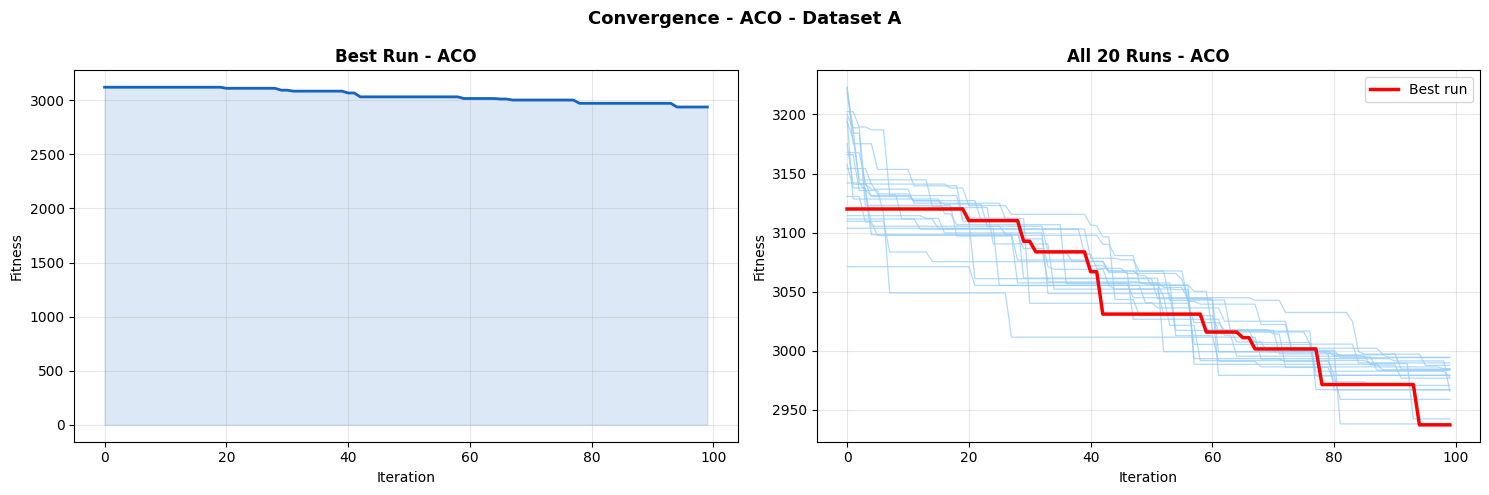

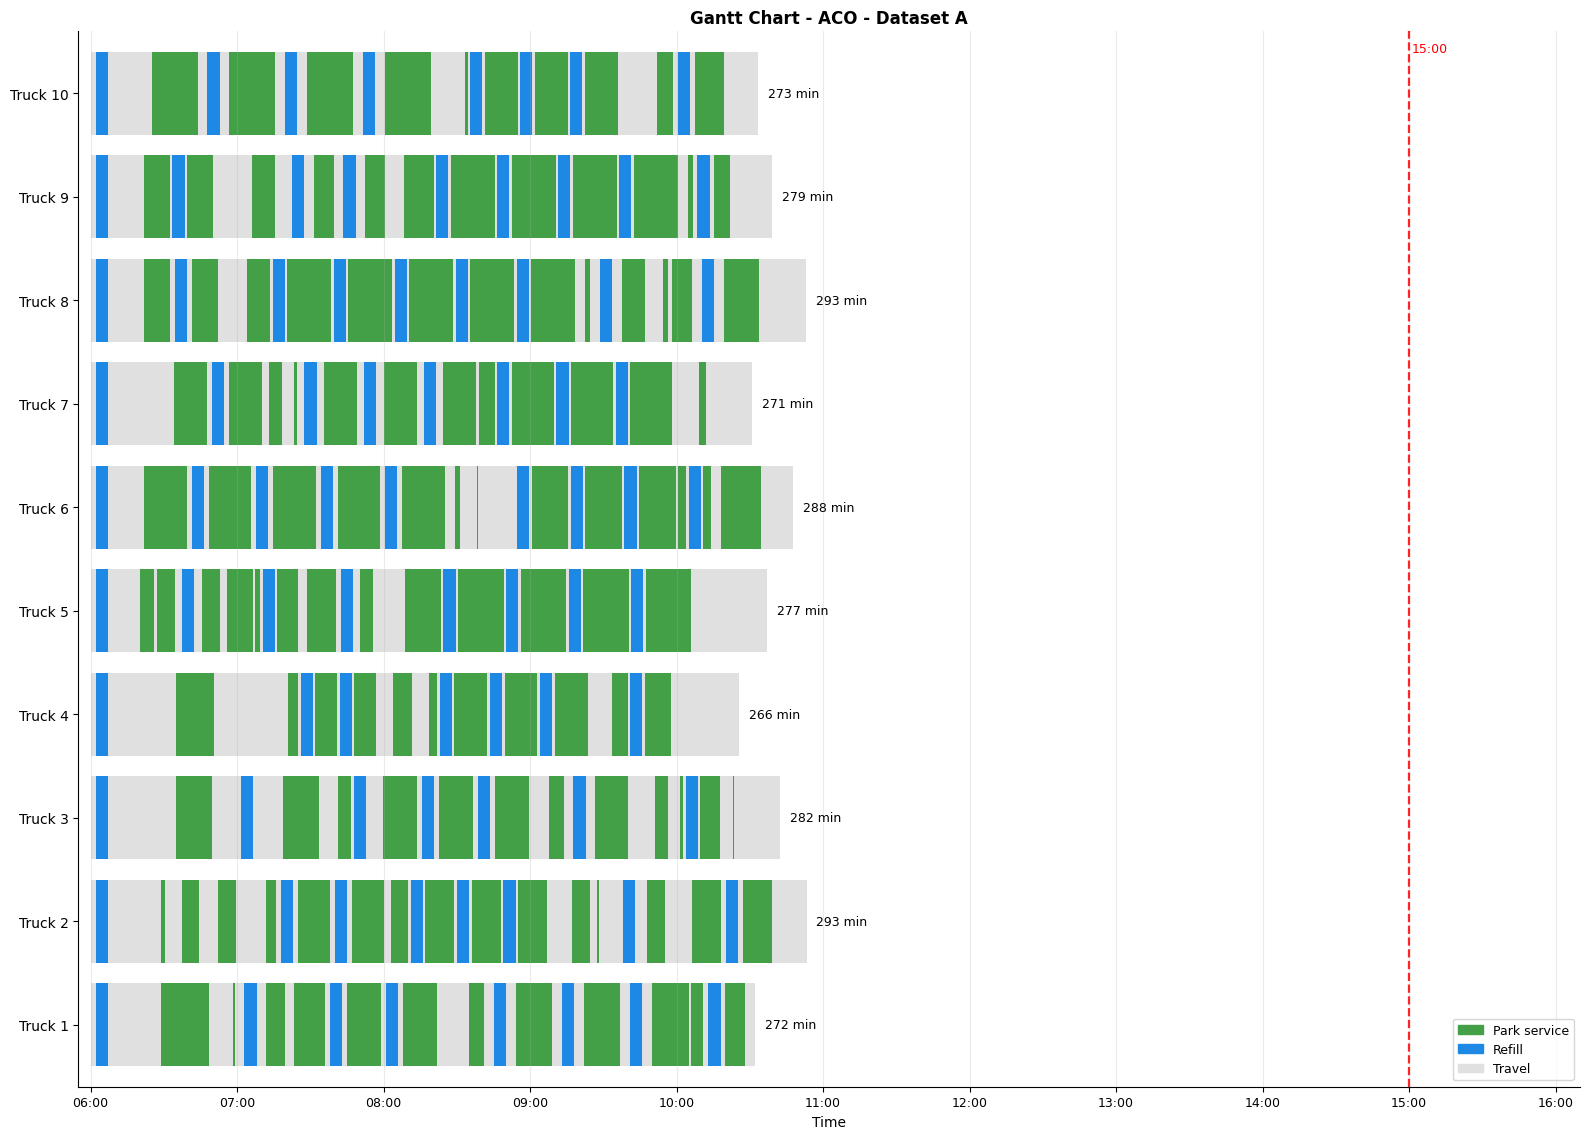

Map saved: output-baseline/DatasetA_ACO_route_map.html

ALNS  |  Dataset A  |  20 runs  |  10 trucks
  Run  1 | fit=  3,081.1 | total= 2933.9 | makespan= 314.0 | std= 11.5 | trucks=10 | refill=73 | feas=True | 10.0s
  Run  2 | fit=  2,931.8 | total= 2784.5 | makespan= 296.0 | std= 12.6 | trucks=10 | refill=73 | feas=True | 9.7s
  Run  3 | fit=  3,131.4 | total= 2986.3 | makespan= 312.3 | std= 11.2 | trucks=10 | refill=72 | feas=True | 10.1s
  Run  4 | fit=  2,985.4 | total= 2838.4 | makespan= 301.5 | std= 10.1 | trucks=10 | refill=73 | feas=True | 9.0s
  Run  5 | fit=  3,032.5 | total= 2889.3 | makespan= 309.2 | std= 11.6 | trucks=10 | refill=71 | feas=True | 9.0s
  Run  6 | fit=  3,000.6 | total= 2853.8 | makespan= 304.5 | std=  8.4 | trucks=10 | refill=73 | feas=True | 9.2s
  Run  7 | fit=  2,986.0 | total= 2840.6 | makespan= 308.0 | std= 13.1 | trucks=10 | refill=72 | feas=True | 9.9s
  Run  8 | fit=  2,971.7 | total= 2826.2 | makespan= 297.0 | std= 14.3 | trucks=10 | refill=72 | fe

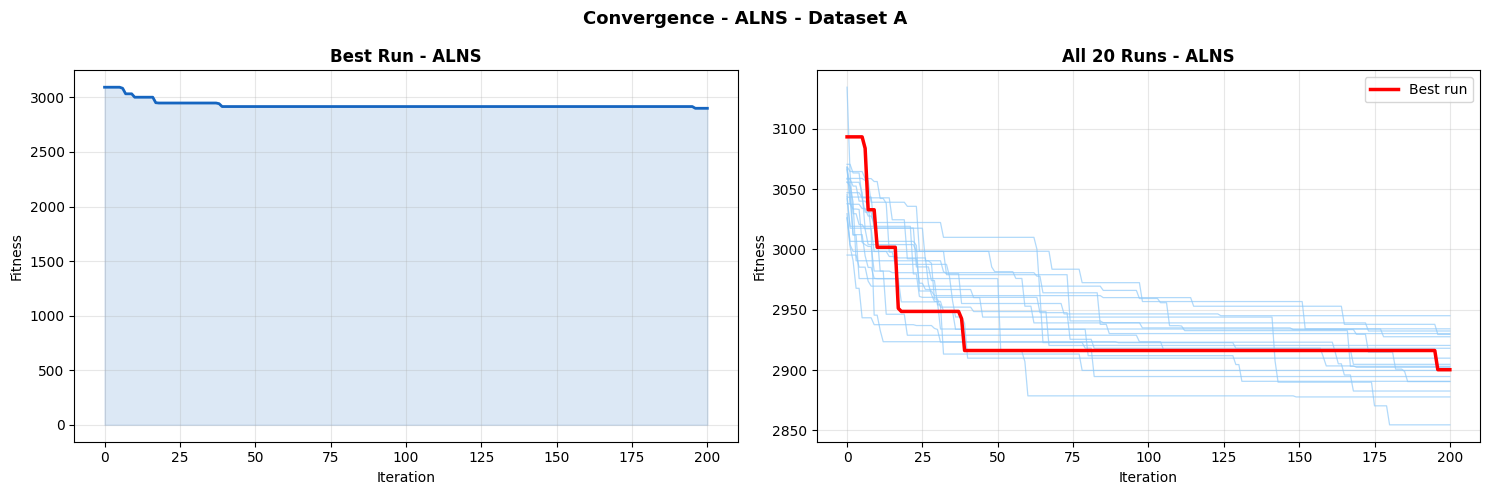

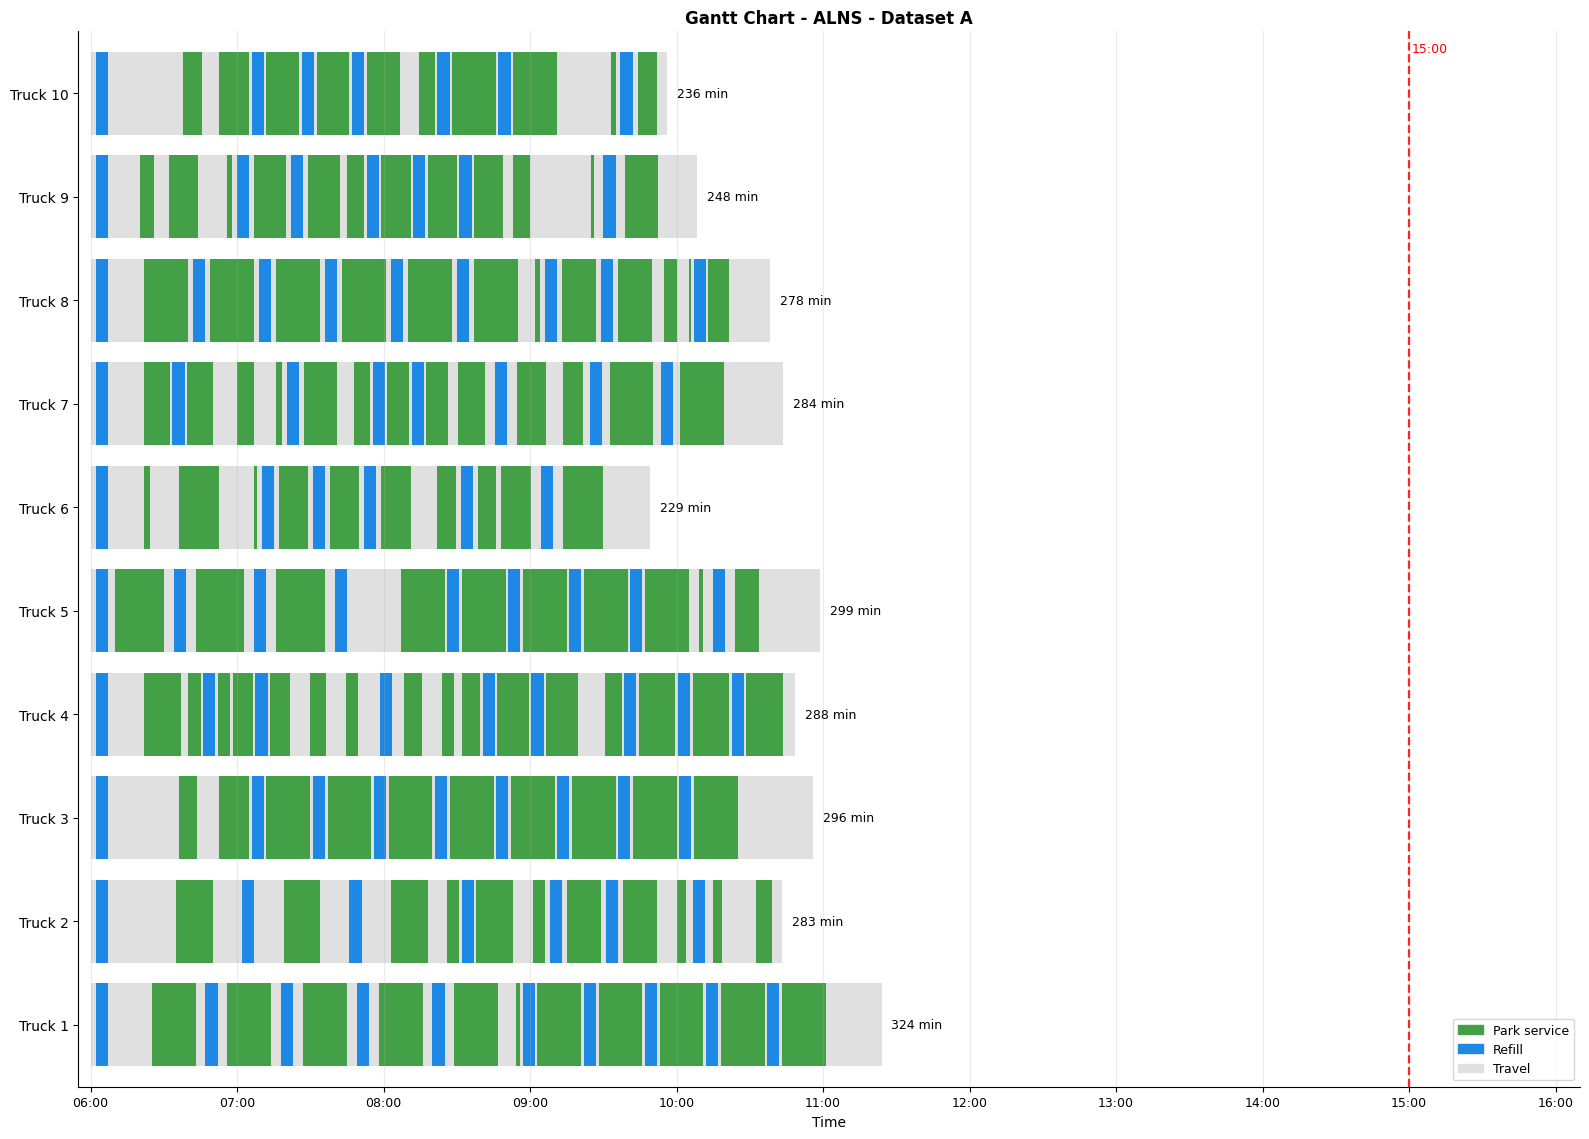

Map saved: output-baseline/DatasetA_ALNS_route_map.html

Hybrid  |  Dataset A  |  20 runs  |  10 trucks
  Run  1 | fit=  2,929.4 | total= 2900.2 | makespan= 312.3 | std= 10.5 | trucks=10 | refill=72 | feas=True | 3.8s
  Run  2 | fit=  2,885.5 | total= 2909.9 | makespan= 309.5 | std= 14.2 | trucks=10 | refill=73 | feas=True | 4.4s
  Run  3 | fit=  2,922.7 | total= 2875.5 | makespan= 305.0 | std= 11.3 | trucks=10 | refill=73 | feas=True | 4.2s
  Run  4 | fit=  2,915.1 | total= 2903.6 | makespan= 315.9 | std= 11.2 | trucks=10 | refill=73 | feas=True | 5.3s
  Run  5 | fit=  2,926.1 | total= 2935.1 | makespan= 311.9 | std= 14.2 | trucks=10 | refill=74 | feas=True | 7.5s
  Run  6 | fit=  2,902.9 | total= 2904.5 | makespan= 303.0 | std= 12.0 | trucks=10 | refill=73 | feas=True | 8.0s
  Run  7 | fit=  2,918.6 | total= 2876.7 | makespan= 302.2 | std=  9.2 | trucks=10 | refill=73 | feas=True | 7.2s
  Run  8 | fit=  2,913.5 | total= 2888.7 | makespan= 310.0 | std= 14.8 | trucks=10 | refill=71 | f

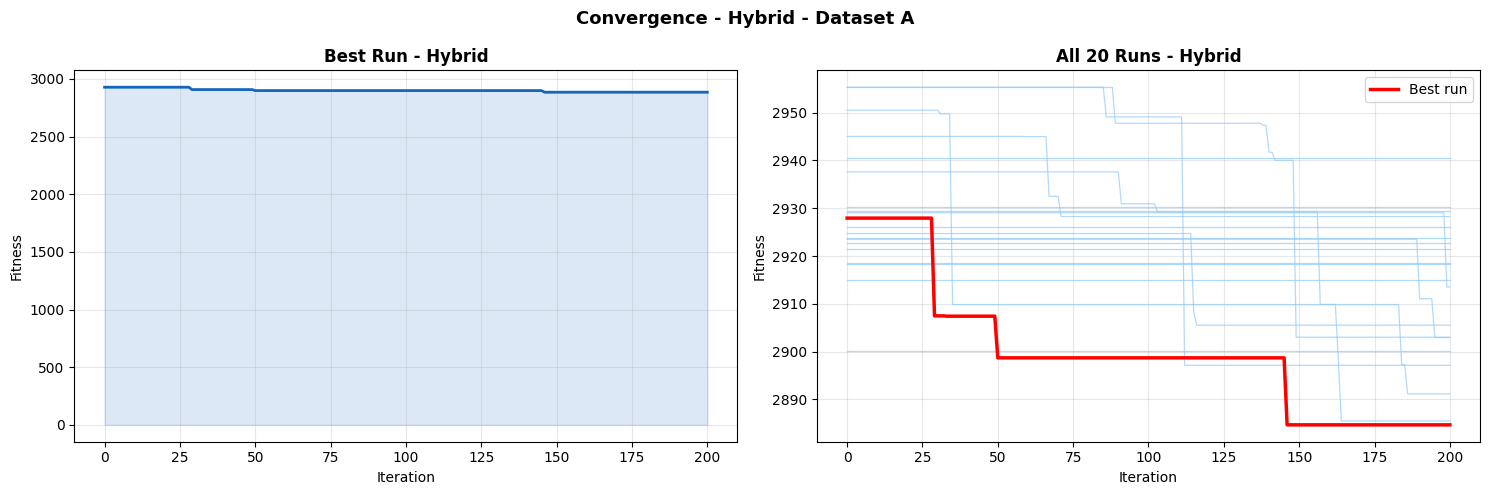

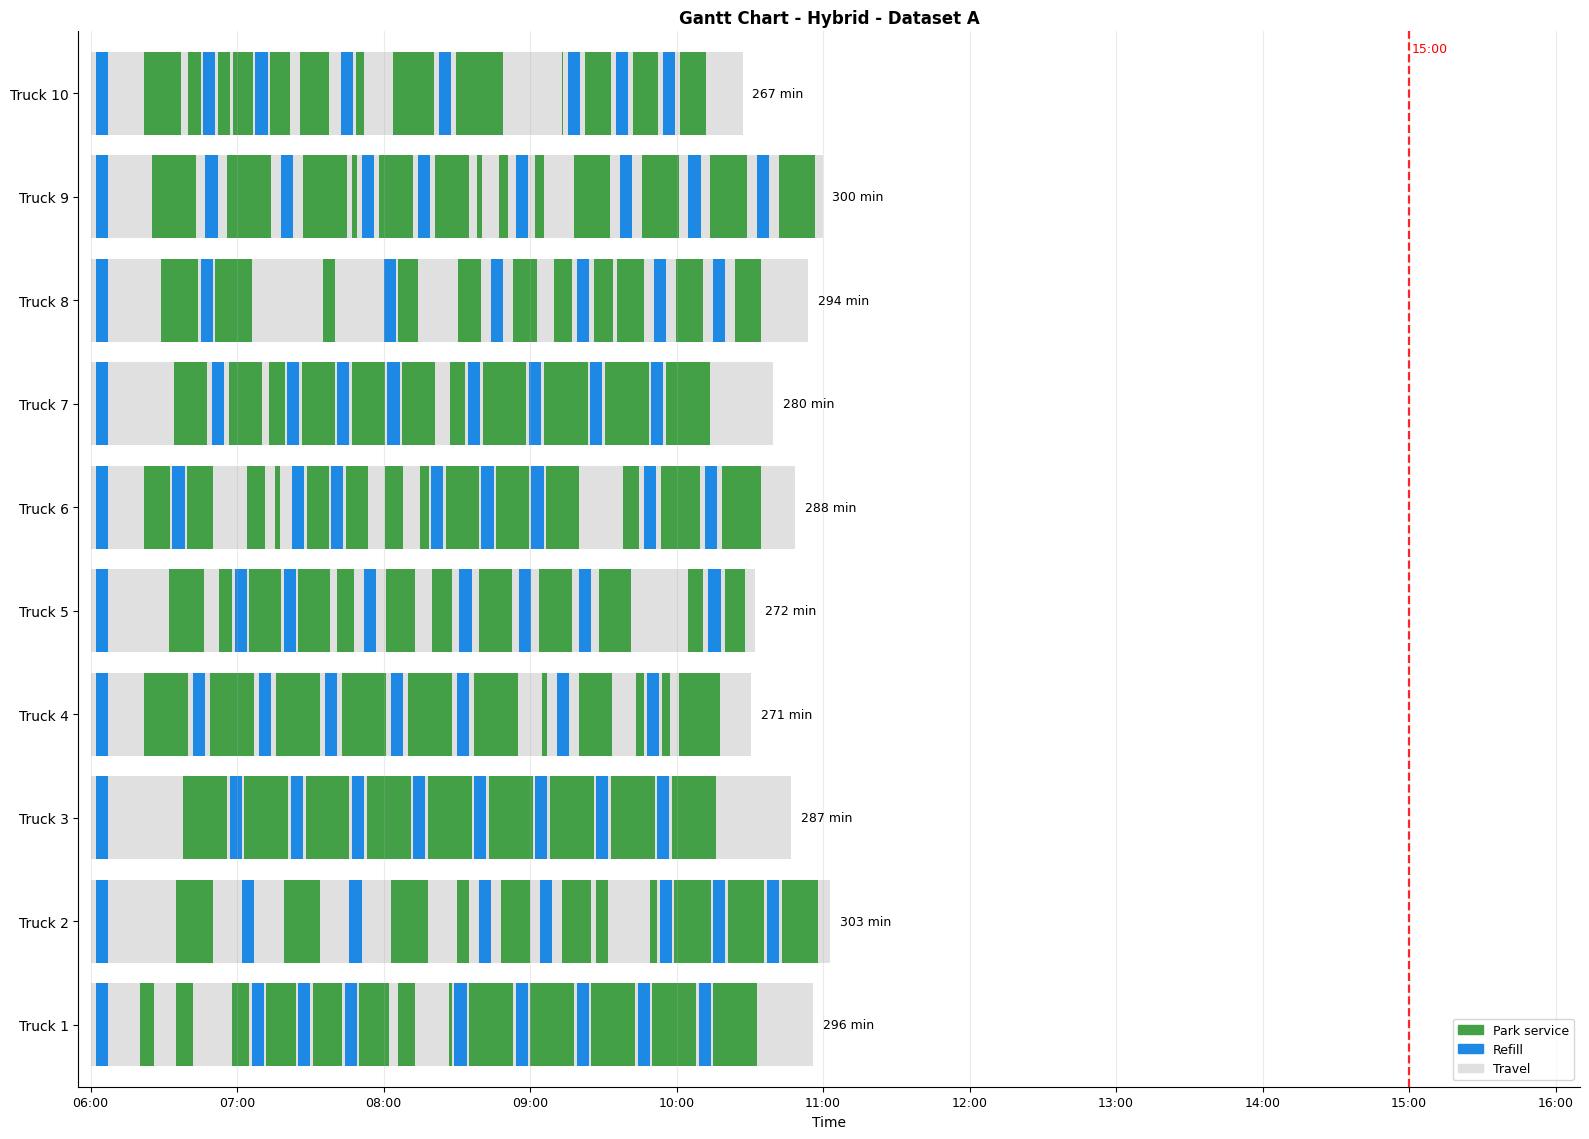

Map saved: output-baseline/DatasetA_Hybrid_route_map.html
Loaded Dataset B: 51 parks, 25 refill stations, depot=0
  Total demand: 264,312 L
  Time matrix shape: (77, 77)

ACO  |  Dataset B  |  20 runs  |  5 trucks
  Run  1 | fit=  1,663.5 | total= 1562.9 | makespan= 319.8 | std=  5.4 | trucks=5 | refill=50 | feas=True | 81.7s
  Run  2 | fit=  1,653.9 | total= 1552.4 | makespan= 334.3 | std= 14.7 | trucks=5 | refill=50 | feas=True | 81.5s
  Run  3 | fit=  1,654.6 | total= 1555.6 | makespan= 324.5 | std=  9.7 | trucks=5 | refill=49 | feas=True | 81.9s
  Run  4 | fit=  1,657.0 | total= 1557.8 | makespan= 323.5 | std= 12.0 | trucks=5 | refill=49 | feas=True | 81.5s
  Run  5 | fit=  1,651.7 | total= 1550.8 | makespan= 324.7 | std=  8.4 | trucks=5 | refill=50 | feas=True | 81.5s
  Run  6 | fit=  1,668.1 | total= 1569.5 | makespan= 321.6 | std=  6.2 | trucks=5 | refill=49 | feas=True | 81.6s
  Run  7 | fit=  1,665.3 | total= 1564.5 | makespan= 323.7 | std=  7.9 | trucks=5 | refill=50 | feas=T

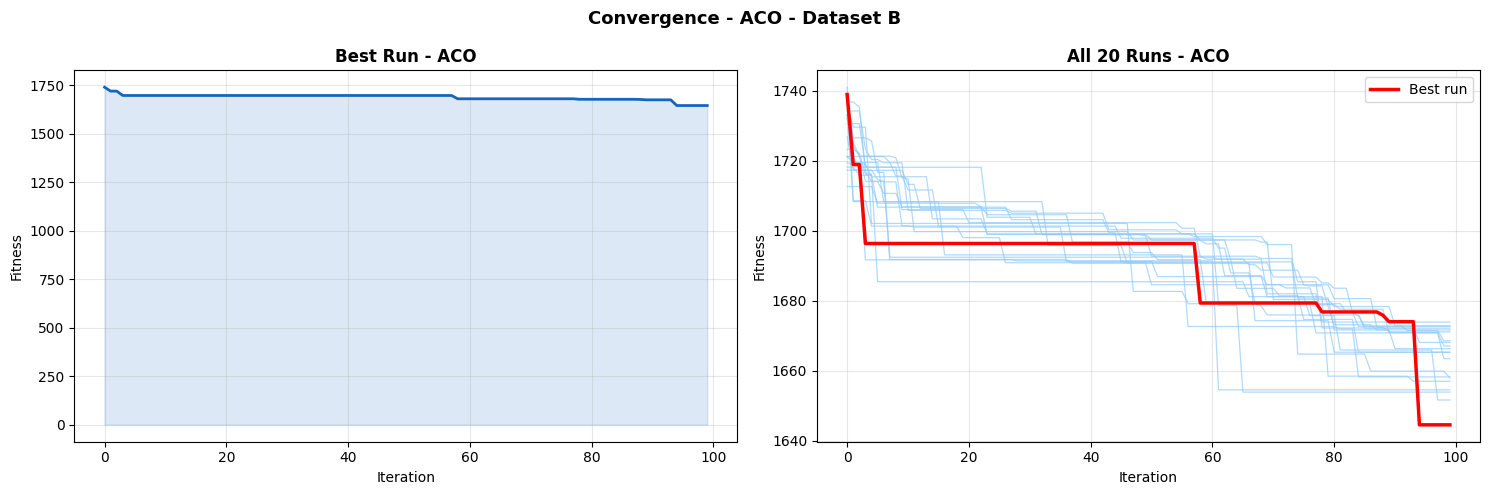

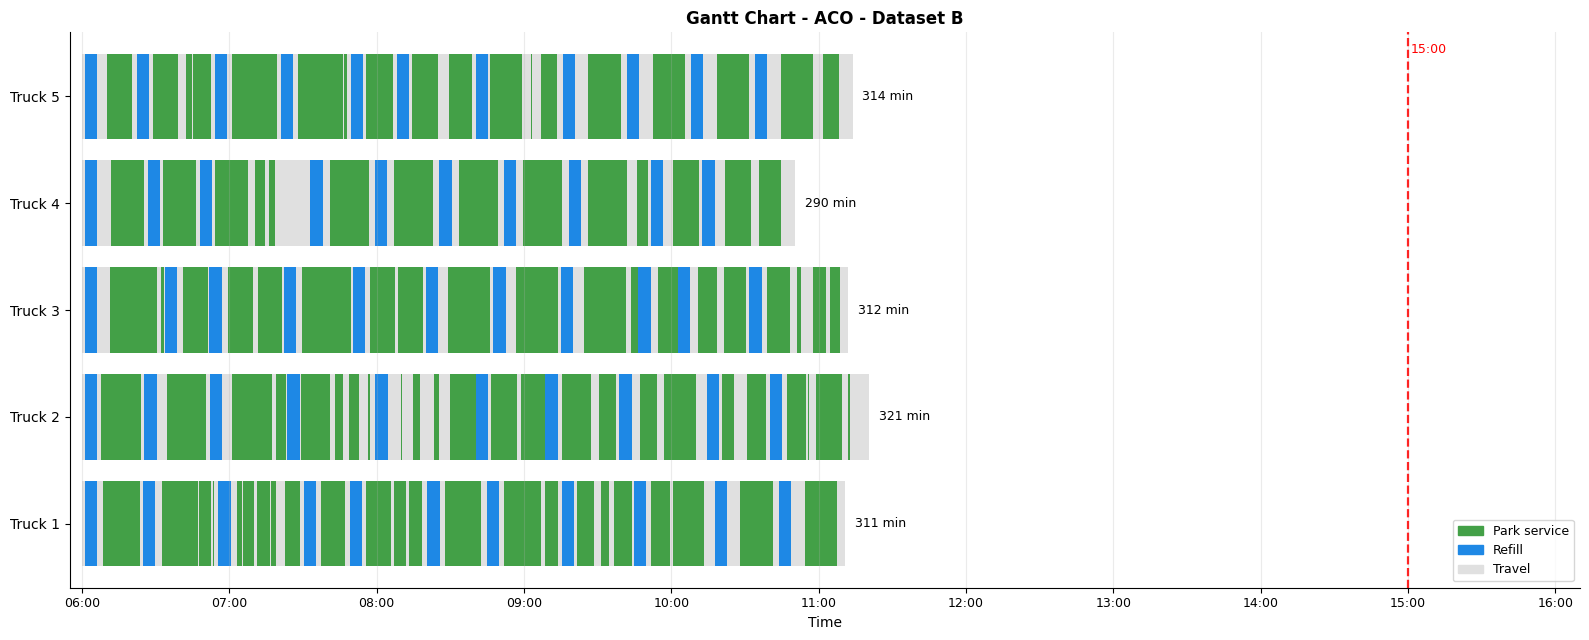

Map saved: output-baseline/DatasetB_ACO_route_map.html

ALNS  |  Dataset B  |  20 runs  |  5 trucks
  Run  1 | fit=  1,665.2 | total= 1563.8 | makespan= 334.6 | std= 14.6 | trucks=5 | refill=50 | feas=True | 4.2s
  Run  2 | fit=  1,706.2 | total= 1604.2 | makespan= 343.6 | std= 19.7 | trucks=5 | refill=50 | feas=True | 4.6s
  Run  3 | fit=  1,684.6 | total= 1583.3 | makespan= 336.9 | std= 12.3 | trucks=5 | refill=50 | feas=True | 5.2s
  Run  4 | fit=  1,642.0 | total= 1540.9 | makespan= 322.0 | std= 11.1 | trucks=5 | refill=50 | feas=True | 4.3s
  Run  5 | fit=  1,679.6 | total= 1578.2 | makespan= 331.0 | std= 14.1 | trucks=5 | refill=50 | feas=True | 4.0s
  Run  6 | fit=  1,634.3 | total= 1535.1 | makespan= 322.4 | std= 11.7 | trucks=5 | refill=49 | feas=True | 4.8s
  Run  7 | fit=  1,656.4 | total= 1555.0 | makespan= 328.5 | std= 13.6 | trucks=5 | refill=50 | feas=True | 5.1s
  Run  8 | fit=  1,641.4 | total= 1543.0 | makespan= 312.9 | std=  4.3 | trucks=5 | refill=49 | feas=True | 4

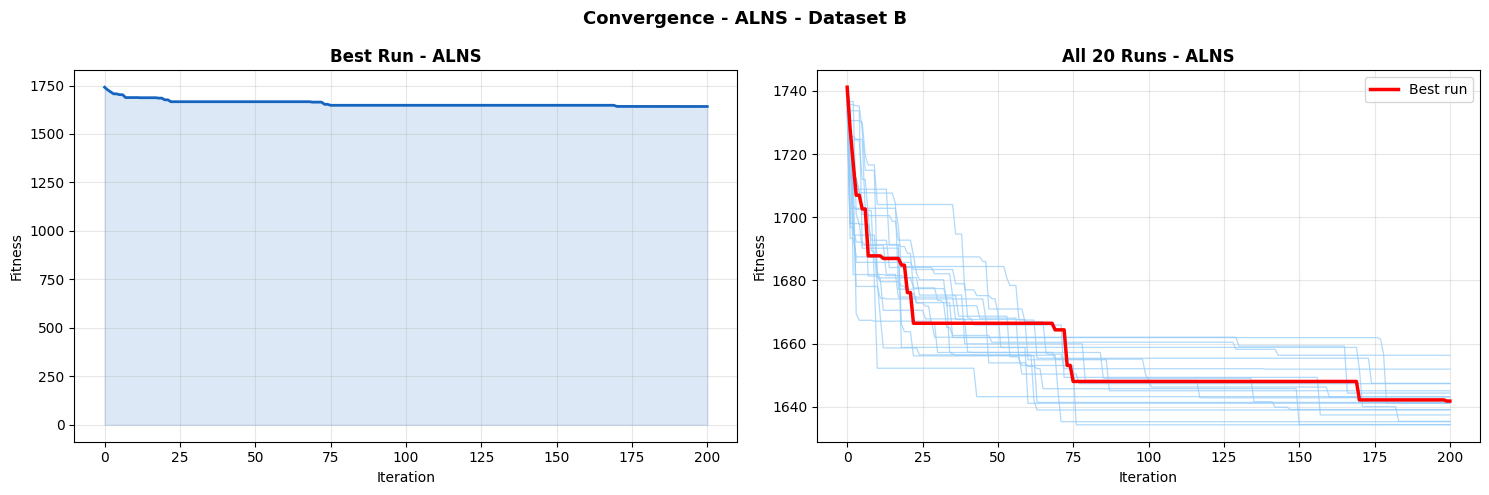

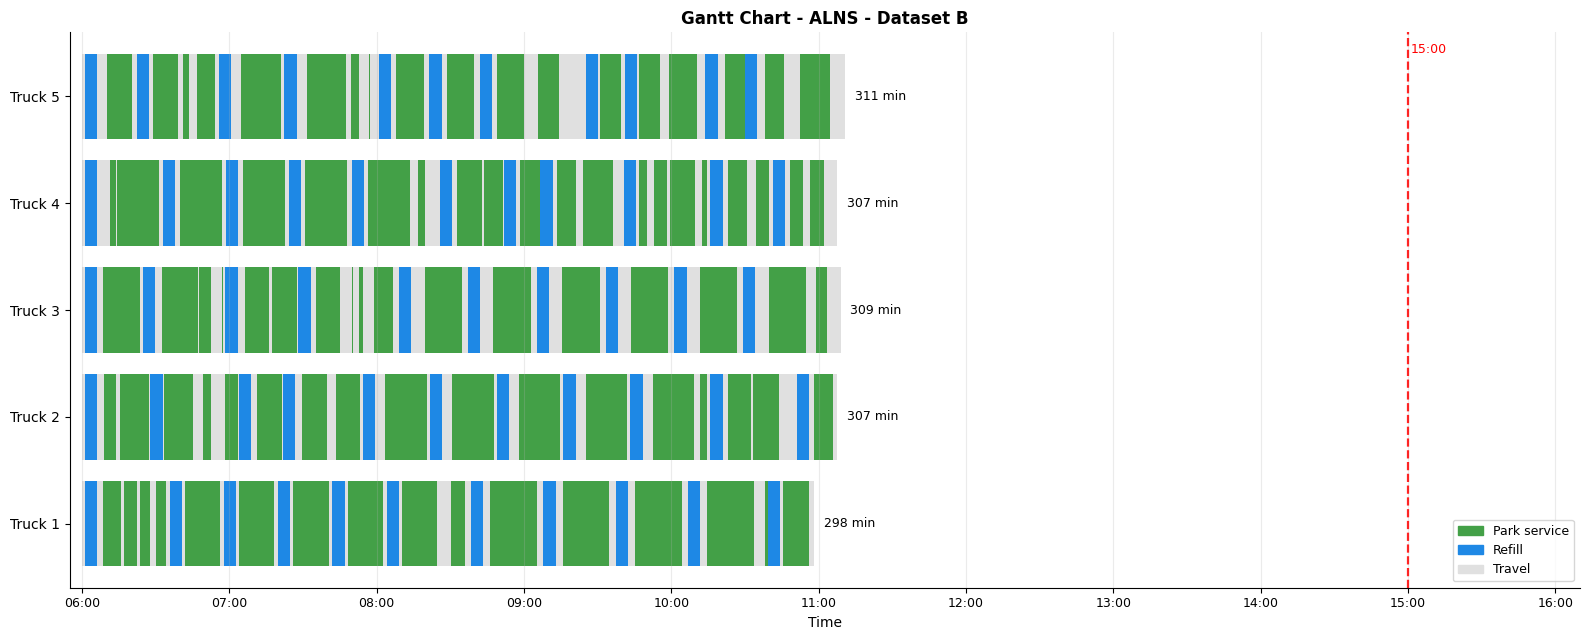

Map saved: output-baseline/DatasetB_ALNS_route_map.html

Hybrid  |  Dataset B  |  20 runs  |  5 trucks
  Run  1 | fit=  1,653.3 | total= 1601.4 | makespan= 327.4 | std=  3.9 | trucks=5 | refill=50 | feas=True | 3.8s
  Run  2 | fit=  1,656.8 | total= 1557.8 | makespan= 323.1 | std=  9.6 | trucks=5 | refill=49 | feas=True | 3.5s
  Run  3 | fit=  1,645.1 | total= 1635.8 | makespan= 348.1 | std= 17.8 | trucks=5 | refill=50 | feas=True | 4.0s
  Run  4 | fit=  1,652.2 | total= 1551.4 | makespan= 319.0 | std=  8.1 | trucks=5 | refill=50 | feas=True | 4.3s
  Run  5 | fit=  1,645.1 | total= 1632.9 | makespan= 348.1 | std= 17.2 | trucks=5 | refill=50 | feas=True | 4.2s
  Run  6 | fit=  1,645.1 | total= 1632.9 | makespan= 348.1 | std= 17.2 | trucks=5 | refill=50 | feas=True | 4.2s
  Run  7 | fit=  1,616.2 | total= 1517.5 | makespan= 315.4 | std=  7.0 | trucks=5 | refill=49 | feas=True | 4.0s
  Run  8 | fit=  1,645.1 | total= 1635.8 | makespan= 348.1 | std= 17.8 | trucks=5 | refill=50 | feas=True 

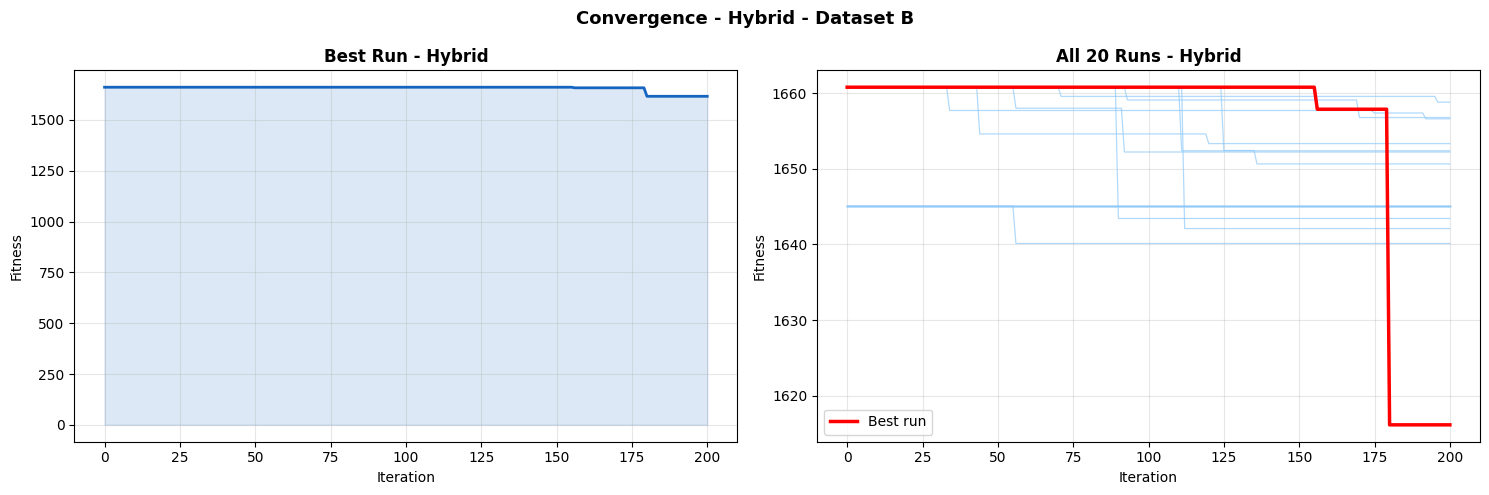

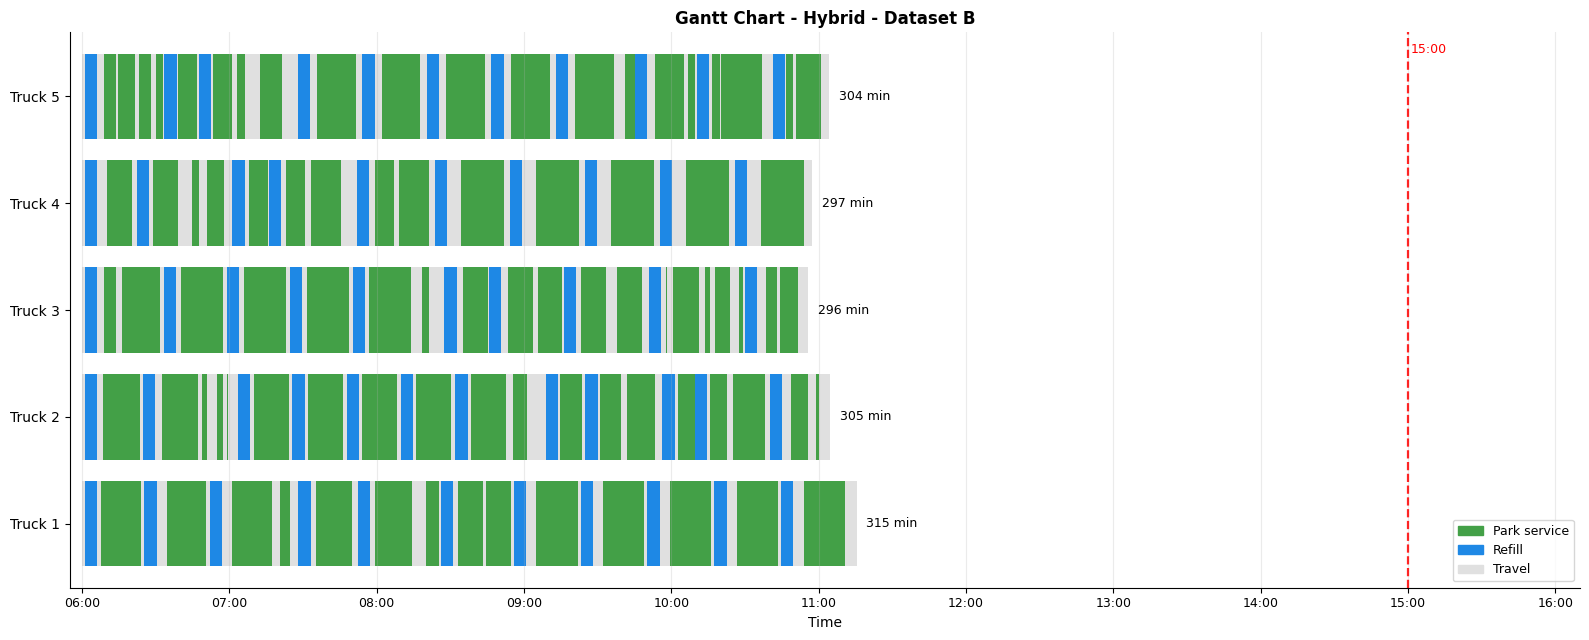

Map saved: output-baseline/DatasetB_Hybrid_route_map.html

All experiments complete.


In [40]:
RESULTS = {}   # (dataset, algo) -> experiment results

for ds_name in DATASETS:
    load_dataset(ds_name)
    for algo_name, (algo_fn, algo_params) in ALGORITHMS.items():
        RESULTS[(ds_name, algo_name)] = run_experiment(
            algo_name, ds_name, algo_fn, algo_params,
            n_runs=N_RUNS, make_plots=True)

print('\nAll experiments complete.')


## 10. Save Results to CSV per Dataset

Minimum output columns per requirement point 6:
`dataset, algorithm, seed, vehicle_count, total_time, makespan, route_time_std, active_vehicles, refill_visits, computation_time, feasible`

In [41]:
all_rows = []
for (ds_name, algo_name), res in RESULTS.items():
    df = res['df']
    for _, row in df.iterrows():
        all_rows.append({
            'dataset'          : ds_name,
            'algorithm'        : algo_name,
            'fitness'          : row['fitness'],
            'seed'             : int(row['run'] * 7),
            'vehicle_count'    : DATASETS[ds_name]['trucks'],
            'total_time'       : row['total_time'],
            'makespan'         : row['makespan'],
            'route_time_std'   : row['route_time_std'],
            'active_vehicles'  : row['active_vehicles'],
            'refill_visits'    : row['refill_visits'],
            'computation_time' : row['computation_time'],
            'feasible'         : row['feasible'],
        })

df_all = pd.DataFrame(all_rows)
df_a = df_all[df_all['dataset'] == 'Dataset A']
df_b = df_all[df_all['dataset'] == 'Dataset B']

df_a.to_csv('output-baseline/baseline_dataset_a.csv', index=False)
df_b.to_csv('output-baseline/baseline_dataset_b.csv', index=False)

print(f'baseline_dataset_a.csv : {len(df_a)} rows')
print(f'baseline_dataset_b.csv : {len(df_b)} rows')
df_all.head(10)


baseline_dataset_a.csv : 60 rows
baseline_dataset_b.csv : 60 rows


,dataset,algorithm,fitness,seed,vehicle_count,total_time,makespan,route_time_std,active_vehicles,refill_visits,computation_time,feasible
0,Dataset A,ACO,2994.41,7,10,2853.36,300.92,10.55,10,70,45.725,True
1,Dataset A,ACO,2942.26,14,10,2801.06,300.25,12.03,10,70,45.972,True
2,Dataset A,ACO,2987.53,21,10,2847.03,291.36,4.97,10,70,45.758,True
3,Dataset A,ACO,2989.66,28,10,2846.43,298.80,12.31,10,71,45.686,True
4,Dataset A,ACO,2937.21,35,10,2794.31,293.20,8.99,10,71,46.920,True
5,Dataset A,ACO,2983.43,42,10,2840.57,295.75,8.55,10,71,45.950,True
6,Dataset A,ACO,2984.81,49,10,2841.58,306.37,12.30,10,71,45.923,True
7,Dataset A,ACO,2970.58,56,10,2829.24,301.80,13.42,10,70,44.974,True
8,Dataset A,ACO,2958.79,63,10,2817.67,307.75,11.20,10,70,44.515,True
9,Dataset A,ACO,2994.10,70,10,2850.87,304.83,12.29,10,71,45.622,True


## 11. Cross-Algorithm Comparison Table

In [42]:
comp_rows = []
for (ds_name, algo_name), res in RESULTS.items():
    df = res['df']
    comp_rows.append({
        'Dataset'            : ds_name,
        'Algorithm'          : algo_name,
        'Best Fitness'       : df['fitness'].min(),
        'Mean Fitness'       : round(df['fitness'].mean(), 1),
        'Std Fitness'        : round(df['fitness'].std(), 1),
        'Mean Total Time'    : round(df['total_time'].mean(), 1),
        'Mean Makespan'      : round(df['makespan'].mean(), 1),
        'Mean Route Std'     : round(df['route_time_std'].mean(), 1),
        'Mean Active Veh'    : round(df['active_vehicles'].mean(), 1),
        'Mean Refill'        : round(df['refill_visits'].mean(), 1),
        'Feasible %'         : round(df['feasible'].mean() * 100, 0),
        'Mean Comp Time (s)' : round(df['computation_time'].mean(), 2),
    })
df_comp = pd.DataFrame(comp_rows)
print('COMPARISON TABLE - mean of', N_RUNS, 'runs')
print('=' * 100)
print(df_comp.to_string(index=False))
df_comp.to_csv('output-baseline/baseline_comparison.csv', index=False)


COMPARISON TABLE - mean of 20 runs
  Dataset Algorithm  Best Fitness  Mean Fitness  Std Fitness  Mean Total Time  Mean Makespan  Mean Route Std  Mean Active Veh  Mean Refill  Feasible %  Mean Comp Time (s)
Dataset A       ACO       2937.21        2973.0         17.4           2830.7          300.1            10.8             10.0         70.6       100.0               54.27
Dataset A      ALNS       2910.54        3002.4         57.5           2856.5          307.4            13.7             10.0         72.3       100.0                9.41
Dataset A    Hybrid       2884.69        2912.9         15.9           2892.3          312.0            14.0             10.0         72.5       100.0                7.05
Dataset B       ACO       1644.55        1663.8          8.3           1564.1          326.7             9.5              5.0         49.4       100.0               80.29
Dataset B      ALNS       1630.97        1661.1         20.7           1560.8          327.7            11.4  

## 12. Comparison Charts

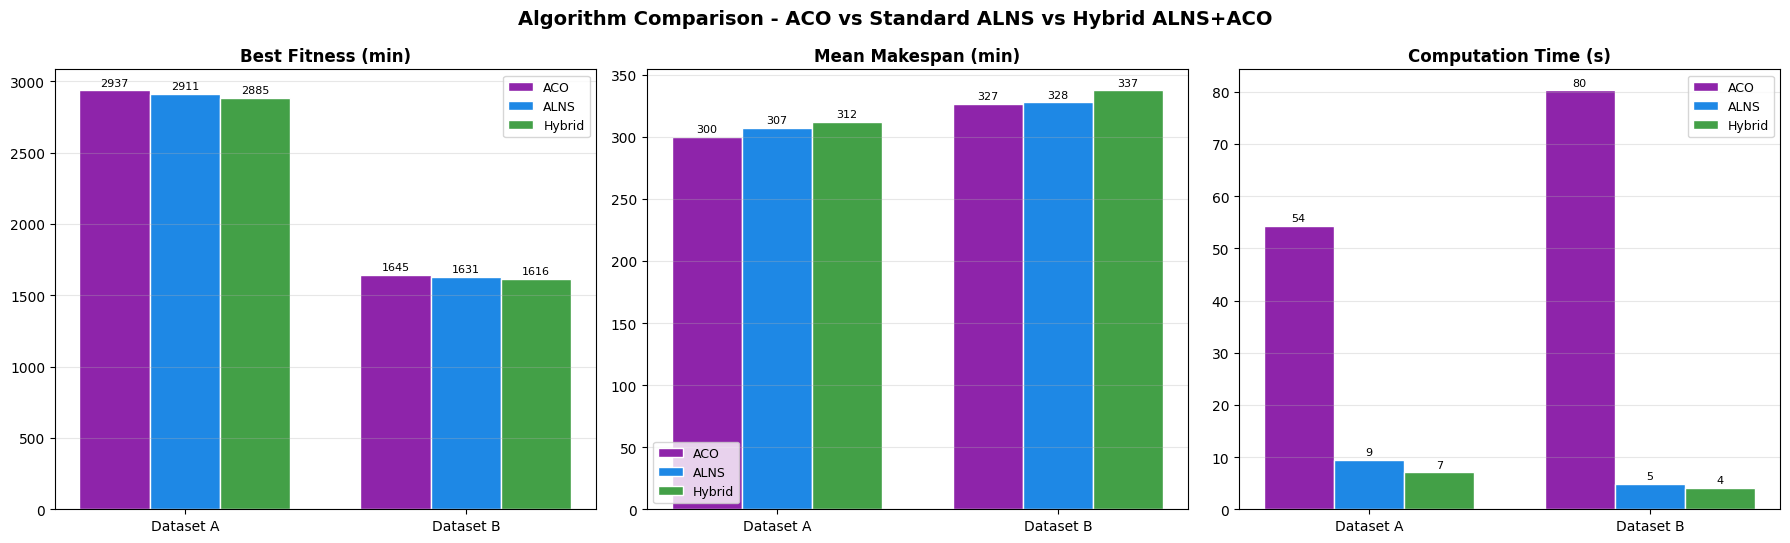

In [43]:
metrics = [('Best Fitness', 'Best Fitness (min)'),
           ('Mean Makespan', 'Mean Makespan (min)'),
           ('Mean Comp Time (s)', 'Computation Time (s)')]
algos = list(ALGORITHMS.keys())
ds_list = list(DATASETS.keys())
palette = {'ACO': '#8E24AA', 'ALNS': '#1E88E5', 'Hybrid': '#43A047'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
x = np.arange(len(ds_list)); width = 0.25
for ax, (mcol, mlabel) in zip(axes, metrics):
    for j, algo in enumerate(algos):
        vals = [df_comp[(df_comp['Dataset'] == ds) & (df_comp['Algorithm'] == algo)][mcol].values[0]
                for ds in ds_list]
        bars = ax.bar(x + (j - 1) * width, vals, width, label=algo,
                      color=palette.get(algo, '#888'), edgecolor='white')
        ax.bar_label(bars, fmt='%.0f', fontsize=8, padding=2)
    ax.set_title(mlabel, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(ds_list)
    ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=9)
fig.suptitle('Algorithm Comparison - ACO vs Standard ALNS vs Hybrid ALNS+ACO',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output-baseline/baseline_comparison.png', dpi=140, bbox_inches='tight')
plt.show(); plt.close(fig)


In [1]:
# Boxplot: total_time distribution per algorithm per dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ds_list):
    data = [df_all[(df_all['dataset']==ds) & (df_all['algorithm']==a)]['total_time'].values
            for a in algos]
    bp = ax.boxplot(data, labels=algos, patch_artist=True)
    for patch, algo in zip(bp['boxes'], algos):
        patch.set_facecolor(palette[algo]); patch.set_alpha(0.6)
    ax.set_title(f'Total Time Distribution - {ds}', fontweight='bold')
    ax.set_ylabel('Total Time (min)'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('output-baseline/baseline_boxplot.png', dpi=150); plt.show()


NameError: name 'plt' is not defined

## 13. Output Files

In [45]:
print('Output files:')
for fn in sorted(os.listdir('output-baseline')):
    sz = os.path.getsize(f'output-baseline/{fn}') / 1024
    print(f'  {fn:<45} ({sz:.1f} KB)')


Output files:
  DatasetA_ACO_convergence.png                  (107.6 KB)
  DatasetA_ACO_gantt.png                        (64.4 KB)
  DatasetA_ACO_route_map.html                   (1267.7 KB)
  DatasetA_ACO_runs.csv                         (1.1 KB)
  DatasetA_ALNS_convergence.png                 (95.3 KB)
  DatasetA_ALNS_gantt.png                       (64.9 KB)
  DatasetA_ALNS_route_map.html                  (1237.9 KB)
  DatasetA_ALNS_runs.csv                        (1.0 KB)
  DatasetA_Hybrid_convergence.png               (68.4 KB)
  DatasetA_Hybrid_gantt.png                     (64.9 KB)
  DatasetA_Hybrid_route_map.html                (1277.7 KB)
  DatasetA_Hybrid_runs.csv                      (1.1 KB)
  DatasetB_ACO_convergence.png                  (103.0 KB)
  DatasetB_ACO_gantt.png                        (40.6 KB)
  DatasetB_ACO_route_map.html                   (793.4 KB)
  DatasetB_ACO_runs.csv                         (1.0 KB)
  DatasetB_ALNS_convergence.png                 (99.7

In [46]:
# Display interactive route maps for best run per algorithm per dataset
for (ds_name, algo_name), res in RESULTS.items():
    best = res['best']
    print(f'\n{"="*50}')
    print(f'{algo_name} - {ds_name} (Best Run #{res["best_run"]})')
    print(f'Total Time: {best["total_time"]:.1f} min | '
          f'Makespan: {best["makespan"]:.1f} min | '
          f'Feasible: {best["feasible"]}')
    print(f'{"="*50}')
    load_dataset(ds_name)
    m = build_route_map(best['solution'], best['dmap'], algo_name, ds_name,
                        f'output-baseline/{ds_name.replace(" ","")}_{algo_name}_route_map.html')
    display(m)


ACO - Dataset A (Best Run #5)
Total Time: 2794.3 min | Makespan: 293.2 min | Feasible: True
Loaded Dataset A: 46 parks, 41 refill stations, depot=0
  Total demand: 389,888 L
  Time matrix shape: (88, 88)
Map saved: output-baseline/DatasetA_ACO_route_map.html



ALNS - Dataset A (Best Run #18)
Total Time: 2765.7 min | Makespan: 324.0 min | Feasible: True
Loaded Dataset A: 46 parks, 41 refill stations, depot=0
  Total demand: 389,888 L
  Time matrix shape: (88, 88)
Map saved: output-baseline/DatasetA_ALNS_route_map.html



Hybrid - Dataset A (Best Run #12)
Total Time: 2857.2 min | Makespan: 303.0 min | Feasible: True
Loaded Dataset A: 46 parks, 41 refill stations, depot=0
  Total demand: 389,888 L
  Time matrix shape: (88, 88)
Map saved: output-baseline/DatasetA_Hybrid_route_map.html



ACO - Dataset B (Best Run #15)
Total Time: 1547.5 min | Makespan: 320.5 min | Feasible: True
Loaded Dataset B: 51 parks, 25 refill stations, depot=0
  Total demand: 264,312 L
  Time matrix shape: (77, 77)
Map saved: output-baseline/DatasetB_ACO_route_map.html



ALNS - Dataset B (Best Run #18)
Total Time: 1532.5 min | Makespan: 310.7 min | Feasible: True
Loaded Dataset B: 51 parks, 25 refill stations, depot=0
  Total demand: 264,312 L
  Time matrix shape: (77, 77)
Map saved: output-baseline/DatasetB_ALNS_route_map.html



Hybrid - Dataset B (Best Run #7)
Total Time: 1517.5 min | Makespan: 315.4 min | Feasible: True
Loaded Dataset B: 51 parks, 25 refill stations, depot=0
  Total demand: 264,312 L
  Time matrix shape: (77, 77)
Map saved: output-baseline/DatasetB_Hybrid_route_map.html
